# Machine Learning for Financial Markets — Complete Project

End-to-end pipeline: Exploratory Data Analysis → Regression & Classification Baselines (XGBoost, LightGBM, Transformer) → ARIMA/GARCH + LightGBM stock-selection strategy → Neural Network Asset Allocation & Portfolio Risk Dashboard.

# Part 1 — Exploratory Data Analysis

We load daily OHLCV data for a universe of stocks and ETFs, compute returns and rolling statistics, and explore cross-asset correlations before any modelling.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import xgboost as xgb
import shap

C:\Users\natha\PycharmProjects\ML_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [21]:
def load_data(folder_path):
    all_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

    dfs = []

    for file in all_files:
        df = pd.read_csv(os.path.join(folder_path, file), parse_dates=['Date'])
        ticker = file.split('_')[0].upper()
        df['Ticker'] = ticker
        dfs.append(df)

    data = pd.concat(dfs, ignore_index=True)
    return data

folder_path = r"C:\Users\natha\PycharmProjects\ML_Project\.venv\Dataset_clean\Stocks clean"

data = load_data(folder_path)

In [7]:
data = data.sort_values(['Ticker', 'Date'])
data.set_index('Date', inplace=True)
data['Return'] = data.groupby('Ticker')['Close'].pct_change()
ticker = data['Ticker'].unique()[0]
df = data[data['Ticker'] == ticker]

print("\n=== BASIC INFO ===")
df.head()


=== BASIC INFO ===


,Open,High,Low,Close,Volume,Ticker,Return
Date,,,,,,,
2005-02-25,92.177,93.031,92.075,92.977,5803401.0,DIA,NaN
2005-02-28,92.763,93.515,92.037,92.414,8688535.0,DIA,-0.006055
2005-03-01,92.474,93.085,92.474,92.867,6192040.0,DIA,0.004902
2005-03-02,92.511,93.266,92.456,92.728,8885876.0,DIA,-0.001497
2005-03-03,93.031,93.247,92.355,92.885,9628615.0,DIA,0.001693


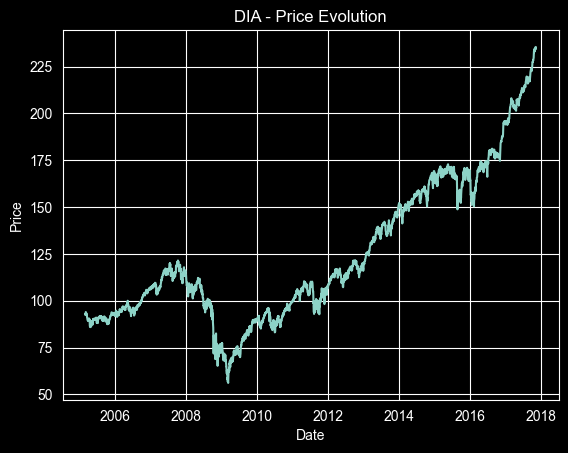

In [8]:
plt.figure()
plt.plot(df.index, df['Close'])
plt.title(f"{ticker} - Price Evolution")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

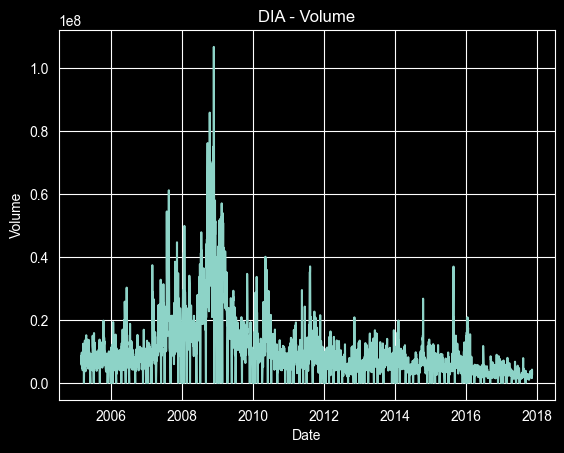

In [9]:
plt.figure()
plt.plot(df.index, df['Volume'])
plt.title(f"{ticker} - Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

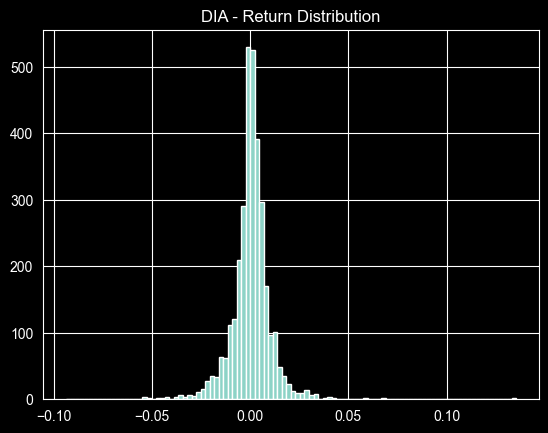

In [10]:
plt.figure()
plt.hist(df['Return'].dropna(), bins=100)
plt.title(f"{ticker} - Return Distribution")
plt.show()

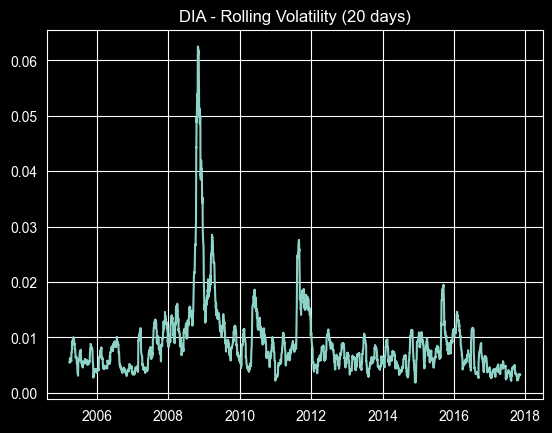

In [11]:
df = df.copy()
df['Volatility'] = df['Return'].rolling(20).std()

plt.figure()
plt.plot(df.index, df['Volatility'])
plt.title(f"{ticker} - Rolling Volatility (20 days)")
plt.show()

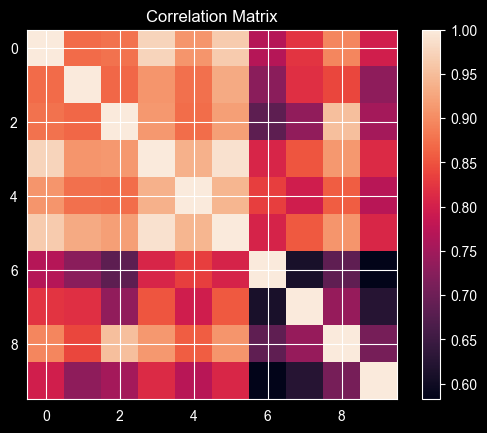

In [12]:
pivot_close = data.pivot_table(values='Close', index=data.index, columns='Ticker')

correlation_matrix = pivot_close.pct_change().corr()

plt.figure()
plt.imshow(correlation_matrix)
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

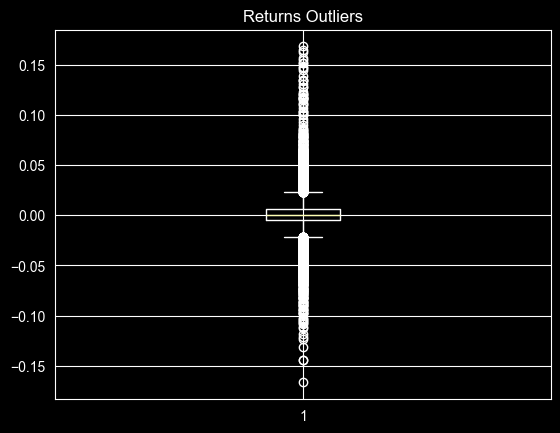

In [14]:
returns = data['Return'].dropna()

plt.figure()
plt.boxplot(returns)
plt.title("Returns Outliers")
plt.show()

In [15]:
sample_tickers = data['Ticker'].unique()[:5]

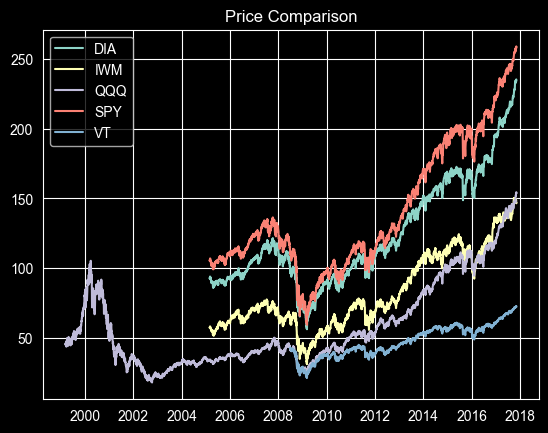

In [16]:
plt.figure()
for t in sample_tickers:
    temp = data[data['Ticker'] == t]
    plt.plot(temp.index, temp['Close'], label=t)

plt.legend()
plt.title("Price Comparison")
plt.show()

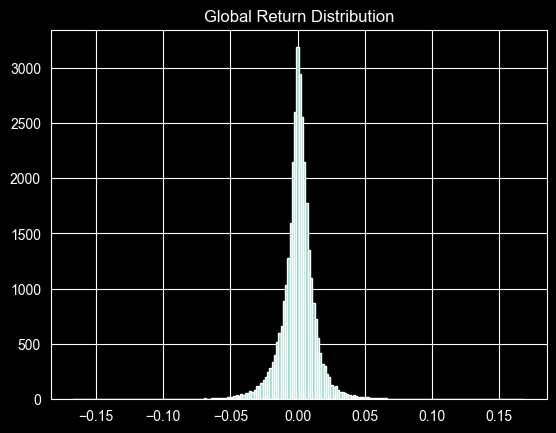

In [17]:
plt.figure()
plt.hist(data['Return'].dropna(), bins=200)
plt.title("Global Return Distribution")
plt.show()

In [18]:
print("Mean return:", data['Return'].mean())
print("Volatility:", data['Return'].std())
print("Max drawdown approx:", (data['Return'].min()))

Mean return: 0.0003583708313269343
Volatility: 0.014481357354356303
Max drawdown approx: -0.16686897848933202


In [19]:
pivot_close = data.pivot_table(values='Close', index=data.index, columns='Ticker')

pivot_close = pivot_close.sort_index()
pivot_close.ffill(inplace=True)
pivot_close.dropna(inplace=True)

print(f"Dataset prêt avec {pivot_close.shape[1]} actifs.")

returns_df = np.log(1 + pivot_close.pct_change())


Dataset prêt avec 10 actifs.


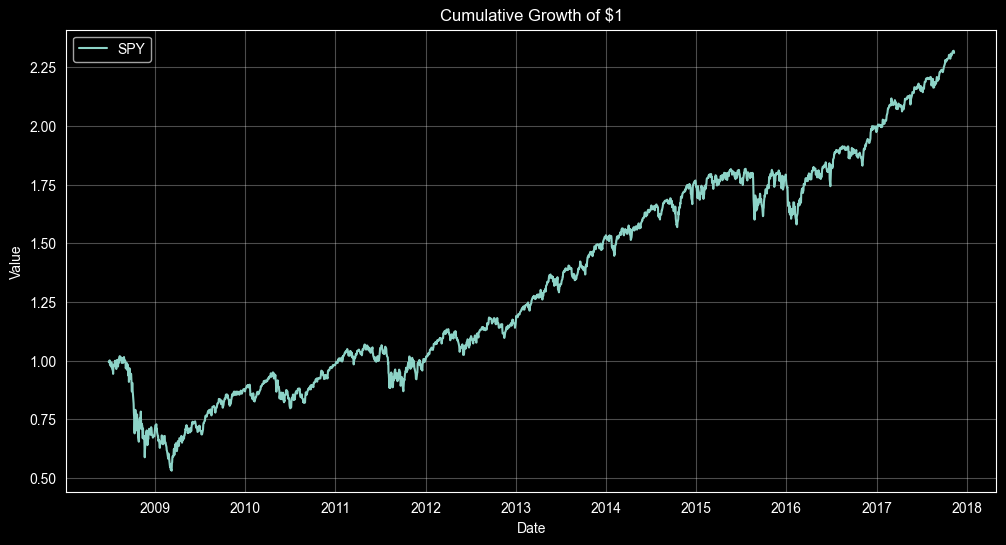

In [20]:
returns_df = np.log(1 + pivot_close.pct_change())

vol_df = returns_df.rolling(window=21).std()

cum_returns = returns_df.cumsum().apply(np.exp)

plt.figure(figsize=(12, 6))

# Vérification que les tickers existent
for ticker in ['SPY', 'NVDA', 'XOM']:
    if ticker in cum_returns.columns:
        plt.plot(cum_returns[ticker], label=ticker)

plt.title("Cumulative Growth of $1")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [32]:


y = (returns_df['AAPL'].shift(-1) > 0).astype(int)

features = [c for c in ['BA', 'AMZN', 'AMD', 'XLF', 'AAPL', 'ABBV', 'NVDA'] if c in returns_df.columns]

X = returns_df[features].iloc[:-1]
y = y.iloc[:-1]


split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [33]:

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

# SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

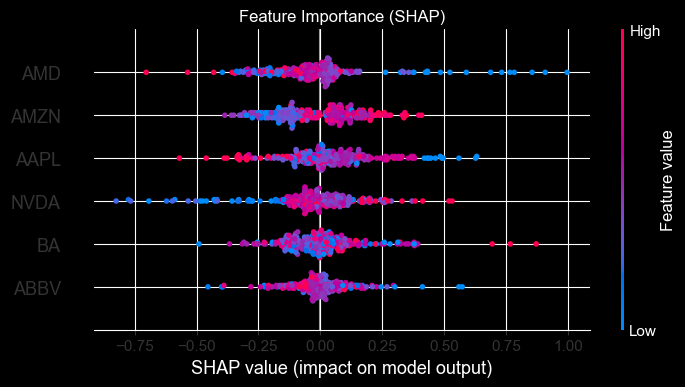

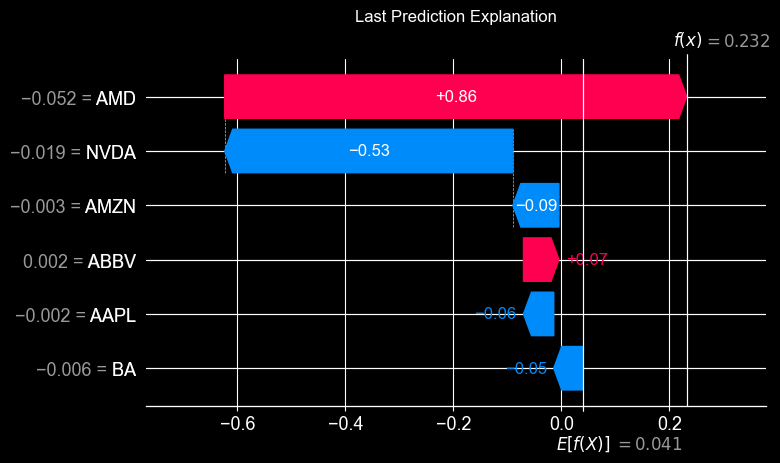

In [34]:
plt.title("Feature Importance (SHAP)")
shap.plots.beeswarm(shap_values)

plt.title("Last Prediction Explanation")
shap.plots.waterfall(shap_values[-1])

---
# Part 2 — S&P 500 Return Prediction (Regression)

Attempt to predict the **next-day SPY return** from same-day constituent returns. Three models — XGBoost, LightGBM, and a Transformer — are evaluated via 5-fold walk-forward validation and compared against a trivial zero-return baseline.

# Daily S&P 500 Return Prediction — Regression Models

Attempt to predict the **next-day SPY return** from the same-day returns of 12 large index constituents.
We compare three models (XGBoost, LightGBM, Transformer), each evaluated with walk-forward validation against a trivial baseline.

## Imports and environment setup

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, mean_absolute_error
import xgboost as xgb
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["MKL_THREADING_LAYER"] = "GNU"
torch.set_num_threads(1)

sns.set_theme(style="whitegrid")

## Data loading
12 large-cap tickers as features, SPY as the target.

In [2]:
core_stocks = ["aapl", "msft", "googl", "amzn", "nvda", "jpm", "bac", "gs", "xom", "gld", "jnj", "ko"]
data_path = "../Data_clean/Stocks clean"
sp500_path = "../Data_clean/ETF clean/spy_clean.csv"
combined_df = pd.DataFrame()

In [3]:
# Load each ticker's closing price into a single combined table (one column per stock)
for ticker in core_stocks:
    file_path = os.path.join(data_path, f"{ticker}_clean.csv")
    temp_df = pd.read_csv(file_path, index_col="Date", parse_dates=True)
    combined_df[ticker] = temp_df["Close"]

# Add SPY closing price as the prediction target
sp500_df = pd.read_csv(sp500_path, index_col="Date", parse_dates=True)

df = combined_df.copy()
df["spy"] = sp500_df["Close"]

In [4]:
df = df.sort_index()

# Trim to the common date range where all tickers have data
start_date = '2005-02-25'
df = df.loc[start_date:]

df.head()

,aapl,msft,googl,amzn,nvda,jpm,bac,gs,xom,gld,jnj,ko,spy
Date,,,,,,,,,,,,,
2005-02-25,5.6975,21.173,92.935,34.99,8.9161,30.812,44.109,100.420,50.892,43.50,53.894,17.546,105.79
2005-02-28,5.7449,21.099,93.995,35.18,8.9625,30.463,43.980,99.241,50.937,43.52,53.390,17.456,105.08
2005-03-01,5.6987,21.199,93.030,35.39,8.9439,30.911,44.384,100.350,49.964,43.22,54.244,17.649,105.62
2005-03-02,5.6499,21.182,92.590,35.50,8.6843,30.828,43.904,100.090,50.433,43.25,54.496,17.555,105.57
2005-03-03,5.3518,21.109,93.505,35.65,8.5635,30.847,43.680,99.790,50.735,42.97,54.324,17.611,105.61


## Features and target

Features: same-day percentage returns of the 12 stocks.
Target: **next-day** SPY return — `shift(-1)` moves tomorrow's return onto today's row, so we predict the future from the present (no look-ahead leakage).

In [5]:
# Features: same-day returns of the 12 stocks
returns_df = df[core_stocks].pct_change()

# Target: next-day SPY return. shift(-1) aligns tomorrow's return with today's features,
# so the model predicts the future from the present (no look-ahead leakage).
returns_df['spy'] = df['spy'].pct_change().shift(-1)

returns_df = returns_df.loc["2005-02-28":]  # drop the first row (NaN from pct_change)
returns_df = returns_df.dropna()            # drop the last row (NaN from shift(-1))
returns_df.head()

,aapl,msft,googl,amzn,nvda,jpm,bac,gs,xom,gld,jnj,ko,spy
Date,,,,,,,,,,,,,
2005-02-28,0.008319,-0.003495,0.011406,0.005430,0.005204,-0.011327,-0.002925,-0.011741,0.000884,0.000460,-0.009352,-0.005129,0.005139
2005-03-01,-0.008042,0.004740,-0.010267,0.005969,-0.002075,0.014706,0.009186,0.011175,-0.019102,-0.006893,0.015996,0.011056,-0.000473
2005-03-02,-0.008563,-0.000802,-0.004730,0.003108,-0.029025,-0.002685,-0.010815,-0.002591,0.009387,0.000694,0.004646,-0.005326,0.000379
2005-03-03,-0.052762,-0.003446,0.009882,0.004225,-0.013910,0.000616,-0.005102,-0.002997,0.005988,-0.006474,-0.003156,0.003190,0.012499
2005-03-04,0.024384,0.000000,-0.005936,0.005610,-0.004356,0.013453,0.009615,0.019341,0.008121,0.009542,0.014837,0.010732,0.000374


## Train/test split

Time-ordered split (`shuffle=False`) — train on the past, test on the future.
Shuffling would leak future information into training and inflate the results.
Then we do a TimeSeriesSplit.

In [6]:
X = returns_df[core_stocks]
y = returns_df["spy"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle = False)

In [7]:
tscv = TimeSeriesSplit(n_splits=5)
X_all = X.values
y_all = y.values

In [8]:
# Baseline 1: always predict zero (no information assumed → expected return = 0)
mae_baseline_zero = mean_absolute_error(y_test, np.zeros_like(y_test))

# Baseline 2: always predict the training-set mean return
mae_baseline_mean = mean_absolute_error(y_test, np.full_like(y_test, y_train.mean()))

print(f"Baseline MAE (zero):  {mae_baseline_zero:.6f}")
print(f"Baseline MAE (mean):  {mae_baseline_mean:.6f}")

Baseline MAE (zero):  0.005130
Baseline MAE (mean):  0.005116


## XGBoost (walk-forward)

Gradient-boosted trees on the 12 same-day returns. A fresh model is trained on each fold,
with the baseline computed **within the same fold** so the comparison is fair across periods of different volatility.

In [9]:
xgb_mae, xgb_base = [], []
for fold, (tr, te) in enumerate(tscv.split(X), start=1):
    X_tr, X_te = X.iloc[tr], X.iloc[te]
    y_tr, y_te = y.iloc[tr], y.iloc[te]
    m = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
    m.fit(X_tr, y_tr)
    mae = mean_absolute_error(y_te, m.predict(X_te))
    base = mean_absolute_error(y_te, np.zeros_like(y_te))
    xgb_mae.append(mae); xgb_base.append(base)
    print(f"Fold {fold}:  MAE={mae:.6f}  |  baseline={base:.6f}  |  improvement={base - mae:+.6f}")
print(f"\nXGB walk-forward:  mean MAE={np.mean(xgb_mae):.6f}  mean improvement={np.mean(xgb_base) - np.mean(xgb_mae):+.6f}")

Fold 1:  MAE=0.013874  |  baseline=0.013638  |  improvement=-0.000236
Fold 2:  MAE=0.007607  |  baseline=0.007397  |  improvement=-0.000210
Fold 3:  MAE=0.007662  |  baseline=0.007518  |  improvement=-0.000145
Fold 4:  MAE=0.005706  |  baseline=0.005626  |  improvement=-0.000080
Fold 5:  MAE=0.004784  |  baseline=0.004689  |  improvement=-0.000094

XGB walk-forward:  mean MAE=0.007927  mean improvement=-0.000153


In [10]:
# Single-split reference for comparison with the walk-forward result above
# (one split = one number; walk-forward is the more reliable estimate)
model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"XGBoost MAE:  {mae:.6f}  |  baseline(zero): {mae_baseline_zero:.6f}  |  improvement: {mae_baseline_zero - mae:+.6f}")

XGBoost MAE:  0.005242  |  baseline(zero): 0.005130  |  improvement: -0.000112


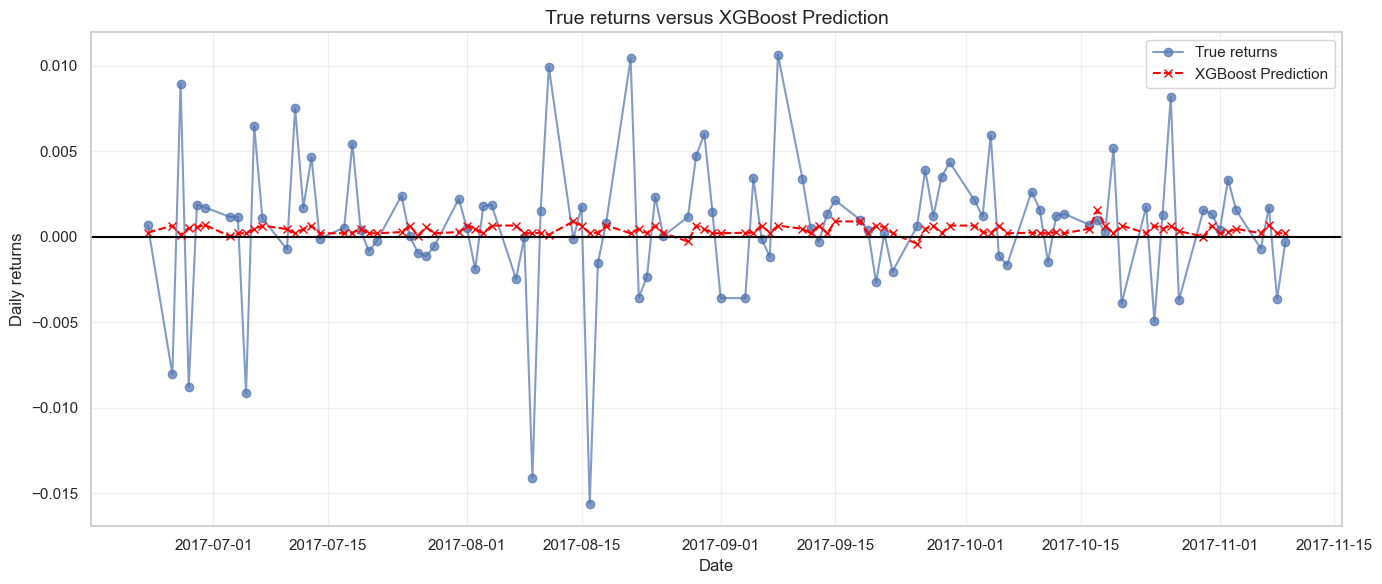

In [11]:
plt.figure(figsize=(14, 6))
last_days = 100
plt.plot(y_test.index[-last_days:], y_test.iloc[-last_days:], 
         label='True returns', marker='o', alpha=0.7)
plt.plot(y_test.index[-last_days:], y_pred[-last_days:], 
         label='XGBoost Prediction', marker='x', linestyle='--', color='red')
plt.title('True returns versus XGBoost Prediction', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily returns', fontsize=12)
plt.axhline(0, color='black', linewidth=1.5, linestyle='-') 

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

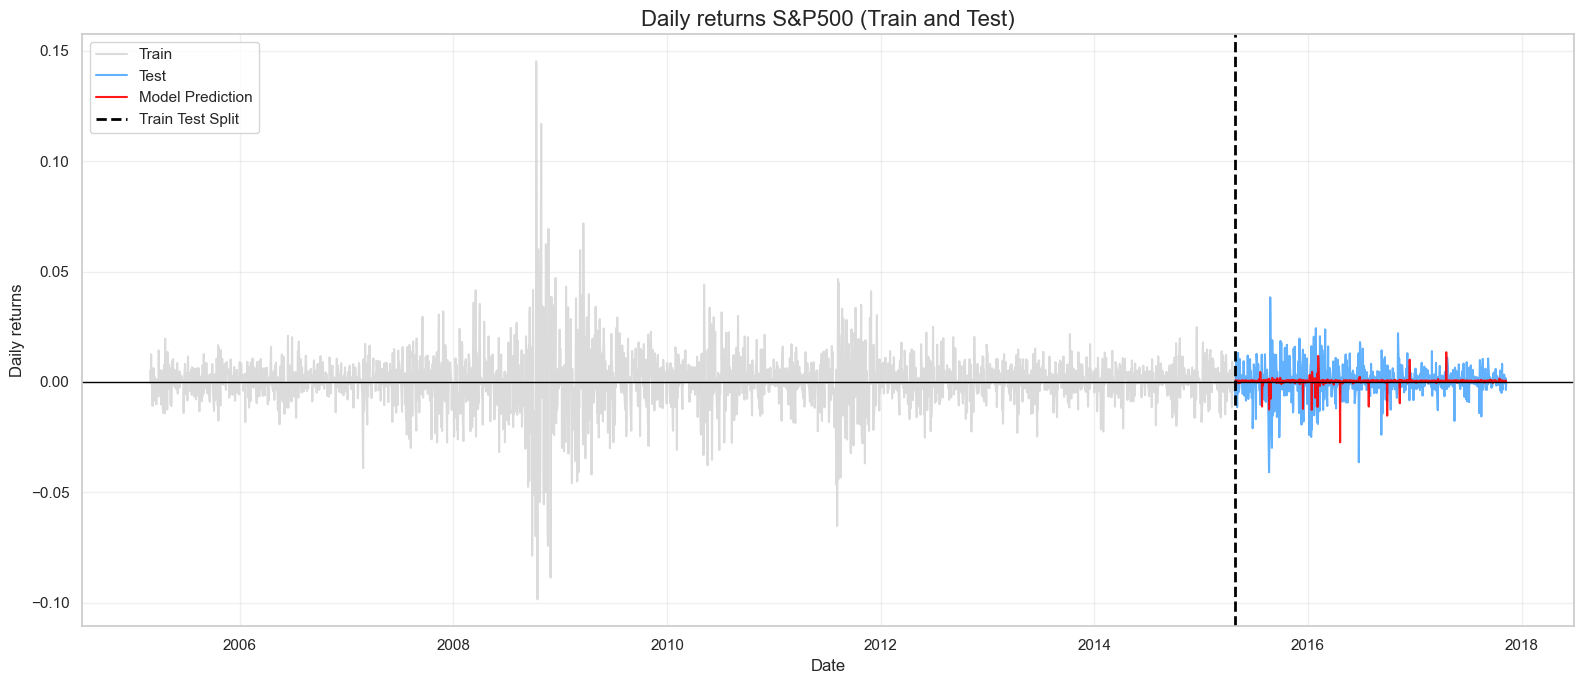

In [12]:
plt.figure(figsize=(16, 7))
plt.plot(y_train.index, y_train, label='Train', color='lightgray', alpha=0.8)
plt.plot(y_test.index, y_test, label='Test', color='dodgerblue', alpha=0.7)
plt.plot(y_test.index, y_pred, label='Model Prediction', color='red', alpha=0.9, linewidth=1.5)
plt.axvline(x=y_test.index[0], color='black', linestyle='--', linewidth=2, label='Train Test Split')
plt.axhline(0, color='black', linewidth=1)
plt.title('Daily returns S&P500 (Train and Test)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily returns', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The prediction (red) stays flat near zero while true returns swing by ±1.5% — the model collapses to the mean, confirming there is no exploitable signal.

## LightGBM (walk-forward)

Same setup as XGBoost — another gradient-boosting library, used here as a cross-check that the result isn't specific to one implementation.

In [13]:
lgbm_mae, lgbm_base = [], []
for fold, (tr, te) in enumerate(tscv.split(X), start=1):
    X_tr, X_te = X.iloc[tr], X.iloc[te]
    y_tr, y_te = y.iloc[tr], y.iloc[te]

    # num_leaves is LightGBM's main complexity control; kept small to avoid overfitting
    m = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, num_leaves=8, max_depth=3, random_state=42, verbose=-1)
    m.fit(X_tr, y_tr)

    mae = mean_absolute_error(y_te, m.predict(X_te))
    base = mean_absolute_error(y_te, np.zeros_like(y_te))
    lgbm_mae.append(mae); lgbm_base.append(base)
    print(f"Fold {fold}:  MAE={mae:.6f}  |  baseline={base:.6f}  |  improvement={base - mae:+.6f}")

print(f"\nLGBM walk-forward:  mean MAE={np.mean(lgbm_mae):.6f}  mean improvement={np.mean(lgbm_base) - np.mean(lgbm_mae):+.6f}")

Fold 1:  MAE=0.013756  |  baseline=0.013638  |  improvement=-0.000117
Fold 2:  MAE=0.007553  |  baseline=0.007397  |  improvement=-0.000155
Fold 3:  MAE=0.007719  |  baseline=0.007518  |  improvement=-0.000201
Fold 4:  MAE=0.005679  |  baseline=0.005626  |  improvement=-0.000053
Fold 5:  MAE=0.004768  |  baseline=0.004689  |  improvement=-0.000078

LGBM walk-forward:  mean MAE=0.007895  mean improvement=-0.000121


In [14]:
# Single-split reference for comparison with the walk-forward result above
# (one split = one number; walk-forward is the more reliable estimate)
model = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, num_leaves=8, max_depth=3, random_state=42, verbose=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"LightGBM MAE:  {mae:.6f}  |  baseline(zero): {mae_baseline_zero:.6f}  |  improvement: {mae_baseline_zero - mae:+.6f}")

LightGBM MAE:  0.005226  |  baseline(zero): 0.005130  |  improvement: -0.000095


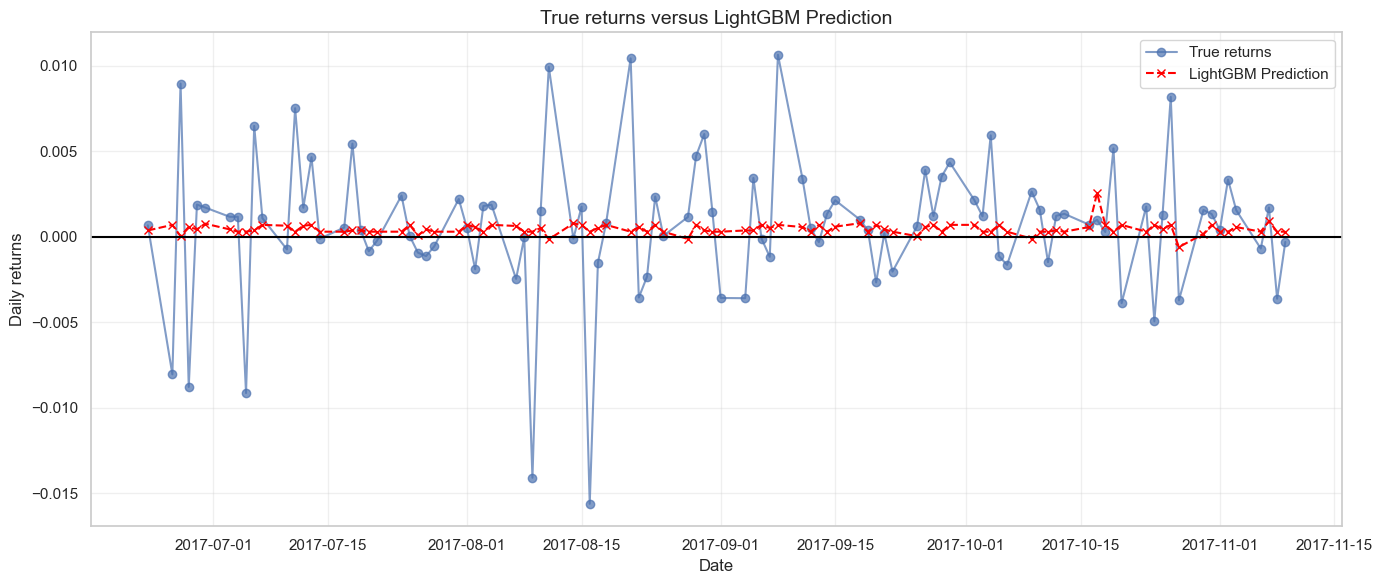

In [15]:
plt.figure(figsize=(14, 6))
last_days = 100
plt.plot(y_test.index[-last_days:], y_test.iloc[-last_days:], 
         label='True returns', marker='o', alpha=0.7)
plt.plot(y_test.index[-last_days:], y_pred[-last_days:], 
         label='LightGBM Prediction', marker='x', linestyle='--', color='red')
plt.title('True returns versus LightGBM Prediction', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily returns', fontsize=12)
plt.axhline(0, color='black', linewidth=1.5, linestyle='-') 

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

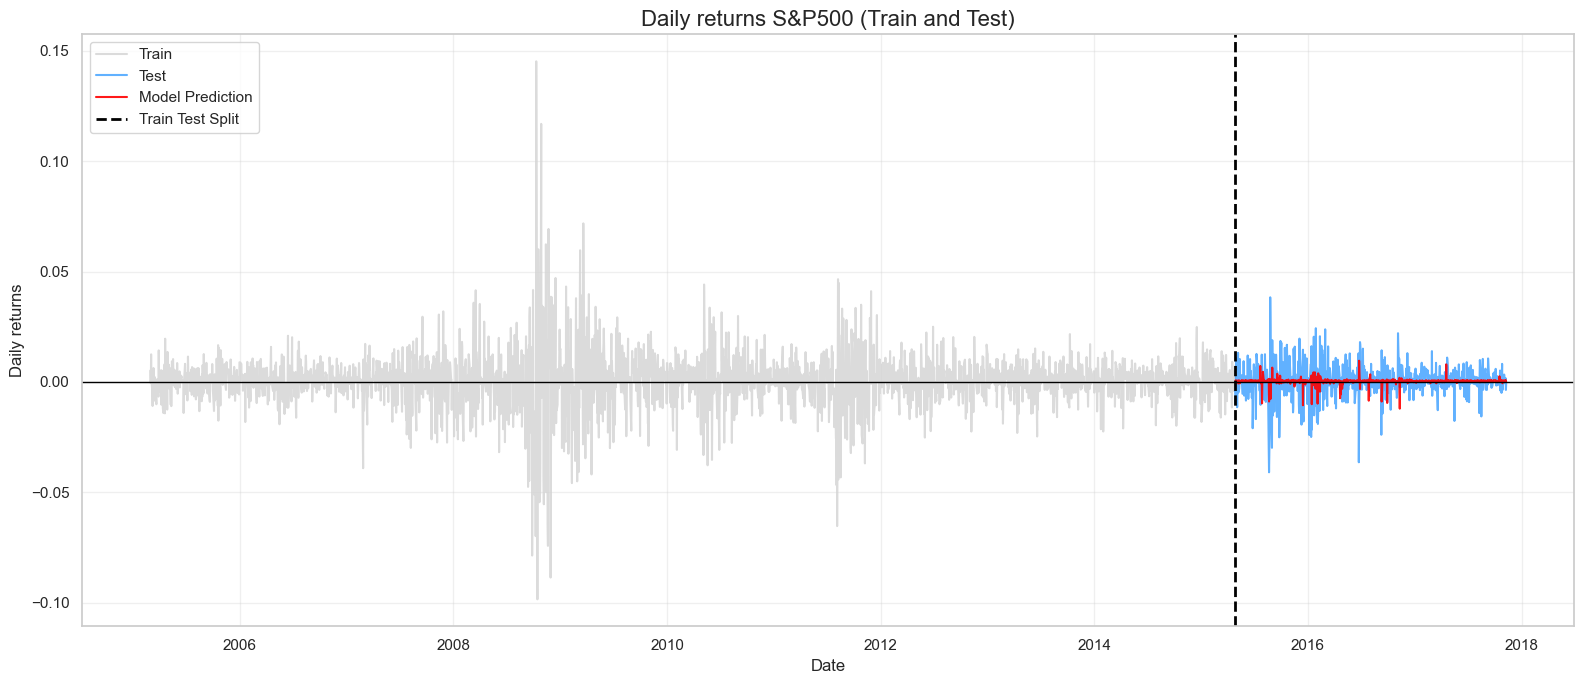

In [16]:
plt.figure(figsize=(16, 7))
plt.plot(y_train.index, y_train, label='Train', color='lightgray', alpha=0.8)
plt.plot(y_test.index, y_test, label='Test', color='dodgerblue', alpha=0.7)
plt.plot(y_test.index, y_pred, label='Model Prediction', color='red', alpha=0.9, linewidth=1.5)
plt.axvline(x=y_test.index[0], color='black', linestyle='--', linewidth=2, label='Train Test Split')
plt.axhline(0, color='black', linewidth=1)
plt.title('Daily returns S&P500 (Train and Test)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily returns', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Same story as XGBoost — the prediction collapses to the mean. Two different libraries, identical behaviour, no exploitable signal.

## Transformer (sequence model)

Unlike the tree models (which see one day at a time), the Transformer takes a **10-day window** of returns and predicts the next day.
Sequencing the data: each sample is 10 consecutive days of features, with the following day's SPY return as the target.

In [17]:
SEQ_LEN = 10  # number of past days the model sees at once

X_values = X.values
y_values = y.values

# Build sliding windows: each sample = SEQ_LEN consecutive days, target = the day right after the window
X_seq = []
y_seq = []
for i in range(len(X_values) - SEQ_LEN):
    window_X = X_values[i : i + SEQ_LEN]
    target_y = y_values[i + SEQ_LEN]
    X_seq.append(window_X)
    y_seq.append(target_y)

# Force a contiguous float32 array — otherwise torch.tensor() converts element-by-element and is very slow
X_seq = np.asarray(X_seq, dtype=np.float32)
y_seq = np.asarray(y_seq, dtype=np.float32)

# Same time-ordered split as before (no shuffling)
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq, y_seq,
    test_size=0.2,
    shuffle=False
)

In [18]:
dates_seq = y.index[SEQ_LEN:]  # one date per target in y_seq
_, dates_test_seq = train_test_split(dates_seq, test_size=0.2, shuffle=False)

In [19]:
class StockTransformer(nn.Module):
    """Transformer encoder for sequence regression.

    Takes a window of SEQ_LEN days (each with `num_features` stock returns) and
    predicts a single value — the next-day SPY return.
    """

    def __init__(self, num_features, seq_len=SEQ_LEN, d_model=64, nhead=4, num_layers=2):
        """
        Args:
            num_features: number of input features per day (here: 12 stocks).
            seq_len: length of the input window (number of past days).
            d_model: internal embedding dimension.
            nhead: number of attention heads (must divide d_model).
            num_layers: number of stacked encoder layers.
        """
        super(StockTransformer, self).__init__()

        # Project the raw features of each day up to the model's embedding dimension
        self.input_layer = nn.Linear(num_features, d_model)

        # Learned positional encoding: without it, attention is order-agnostic and the
        # model couldn't tell day 1 from day 10 — essential for time-series data
        self.pos_embedding = nn.Parameter(torch.zeros(1, seq_len, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            batch_first=True,
            dim_feedforward=128,
            dropout=0.1
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Map the encoded sequence to a single regression output
        self.output_layer = nn.Linear(d_model, 1)

    def forward(self, x):
        """Run one forward pass; returns the predicted next-day return per sample."""
        x = self.input_layer(x)
        x = x + self.pos_embedding          # inject day-order information
        x = self.transformer_encoder(x)
        x = x[:, -1, :]                     # use the last day's representation as the summary
        out = self.output_layer(x)
        return out.squeeze()


num_features = X_train_seq.shape[2]
model = StockTransformer(num_features=num_features)
print(model)

StockTransformer(
  (input_layer): Linear(in_features=12, out_features=64, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
)


In [20]:
# StandardScaler works on 2D data, but our sequences are 3D (samples, days, features).
# Flatten to 2D, scale, then reshape back to the original 3D shape.
BATCH_SIZE = 32
y_train_t = torch.tensor(y_train_seq, dtype=torch.float32)
y_test_t = torch.tensor(y_test_seq, dtype=torch.float32)

samples_train, seq_len, features = X_train_seq.shape
X_train_2d = X_train_seq.reshape(-1, features)

samples_test, _, _ = X_test_seq.shape
X_test_2d = X_test_seq.reshape(-1, features)

# Fit on train only, apply to test — prevents test-set information leaking into scaling
scaler = StandardScaler()
X_train_scaled_2d = scaler.fit_transform(X_train_2d)
X_test_scaled_2d = scaler.transform(X_test_2d)

# Restore the (samples, days, features) shape the Transformer expects
X_train_seq_scaled = X_train_scaled_2d.reshape(samples_train, seq_len, features)
X_test_seq_scaled = X_test_scaled_2d.reshape(samples_test, seq_len, features)

X_train_t = torch.tensor(X_train_seq_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_seq_scaled, dtype=torch.float32)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = TensorDataset(X_test_t, y_test_t)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
model = StockTransformer(num_features=features)

# L1Loss = MAE, the same metric we evaluate on, so the model optimizes exactly what we measure
criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

EPOCHS = 200

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()              # reset gradients from the previous step
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()                    # compute gradients
        optimizer.step()                   # update weights
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch + 1}/{EPOCHS}] | Average Training Loss: {avg_loss:.6f}")

Epoch [1/200] | Average Training Loss: 0.220160
Epoch [10/200] | Average Training Loss: 0.033193
Epoch [20/200] | Average Training Loss: 0.017520
Epoch [30/200] | Average Training Loss: 0.013238
Epoch [40/200] | Average Training Loss: 0.011095
Epoch [50/200] | Average Training Loss: 0.010120
Epoch [60/200] | Average Training Loss: 0.009456
Epoch [70/200] | Average Training Loss: 0.008842


In [ ]:
model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        all_preds.extend(model(batch_X).numpy())
        all_true.extend(batch_y.numpy())

# True per-sample MAE (not an average of per-batch averages, which the uneven last batch would skew)
test_mae = mean_absolute_error(all_true, all_preds)
baseline_mae = mean_absolute_error(all_true, np.zeros_like(all_true))

print(f"Transformer Test MAE:  {test_mae:.6f}  |  baseline(zero): {baseline_mae:.6f}  |  improvement: {baseline_mae - test_mae:+.6f}")

Transformer Test MAE:  0.005718  |  baseline(zero): 0.005125  |  improvement: -0.000594


Transformer MAE:  0.005718
Baseline MAE:     0.005125
Improvement:      -0.000594


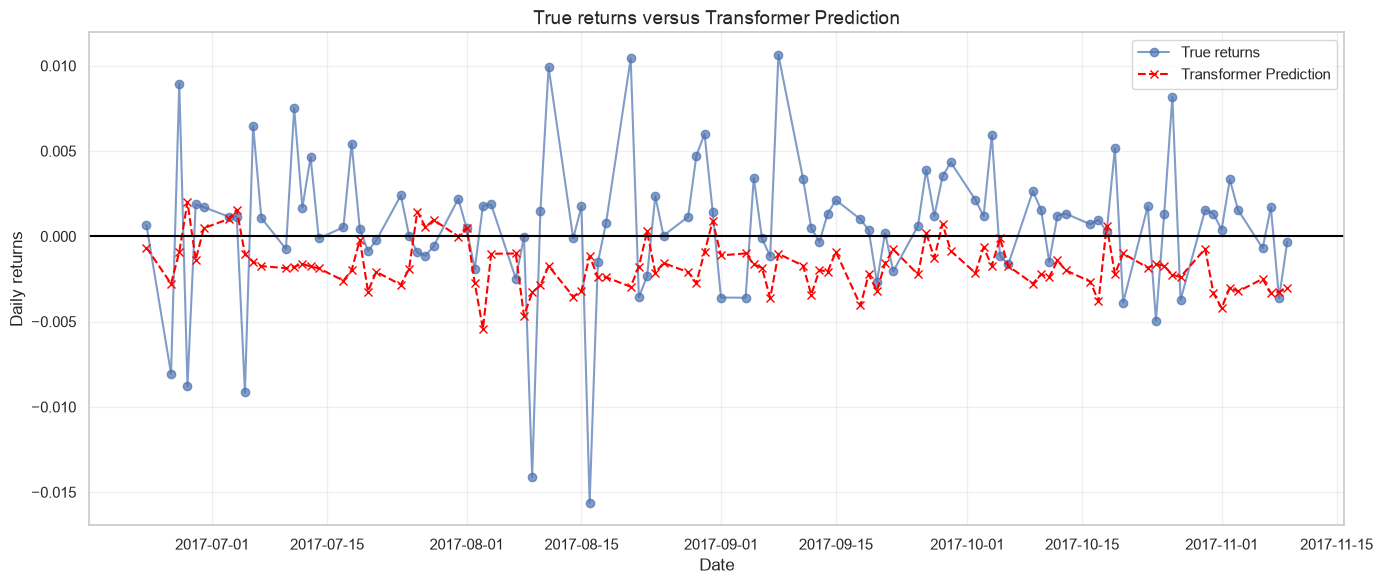

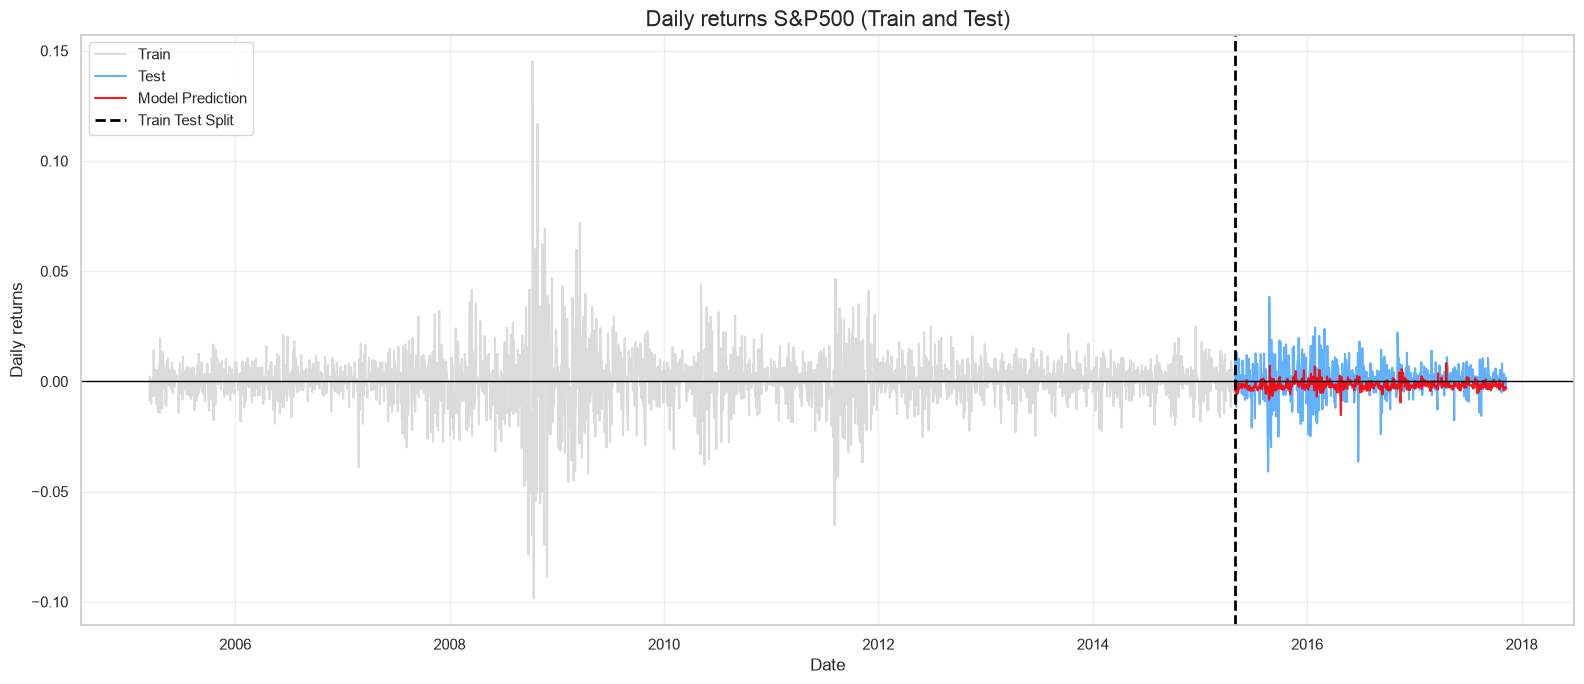

In [ ]:
model.eval()
all_predictions = []
all_actuals = []

# Collect predictions over the whole test set, then compute MAE once (per-sample, not per-batch)
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        preds = model(batch_X)
        all_predictions.extend(preds.numpy())
        all_actuals.extend(batch_y.numpy())

all_predictions = np.array(all_predictions)
all_actuals = np.array(all_actuals)

mae_transformer = mean_absolute_error(all_actuals, all_predictions)
mae_baseline_seq = mean_absolute_error(all_actuals, np.zeros_like(all_actuals))

print(f"Transformer MAE:  {mae_transformer:.6f}")
print(f"Baseline MAE:     {mae_baseline_seq:.6f}")
print(f"Improvement:      {mae_baseline_seq - mae_transformer:+.6f}")

# Plot 1 — last 100 test days: prediction vs reality
plt.figure(figsize=(14, 6))
last_days = 100
plt.plot(dates_test_seq[-last_days:], all_actuals[-last_days:],
         label='True returns', marker='o', alpha=0.7)
plt.plot(dates_test_seq[-last_days:], all_predictions[-last_days:],
         label='Transformer Prediction', marker='x', linestyle='--', color='red')
plt.title('True returns versus Transformer Prediction', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily returns', fontsize=12)
plt.axhline(0, color='black', linewidth=1.5, linestyle='-')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2 — full train + test view with the split marked
train_dates_seq = y.index[SEQ_LEN: SEQ_LEN + len(y_train_seq)]
plt.figure(figsize=(16, 7))
plt.plot(train_dates_seq, y_train_seq, label='Train', color='lightgray', alpha=0.8)
plt.plot(dates_test_seq, all_actuals, label='Test', color='dodgerblue', alpha=0.7)
plt.plot(dates_test_seq, all_predictions, label='Model Prediction', color='red', alpha=0.9, linewidth=1.5)
plt.axvline(x=dates_test_seq[0], color='black', linestyle='--', linewidth=2, label='Train Test Split')
plt.axhline(0, color='black', linewidth=1)
plt.title('Daily returns S&P500 (Train and Test)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily returns', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The Transformer's prediction (red) moves but doesn't track the true returns — movement without direction. That's why its MAE is worse than the flat zero-baseline.

### Transformer — walk-forward

The same 5-fold walk-forward used for the tree models, so all three are evaluated on equal footing.
Scaling and sequence-building happen **inside each fold** (fit on that fold's training part only) to avoid leakage across folds.

In [ ]:
SEQ_LEN = 10
EPOCHS = 15      # fewer epochs than the single-split run: this trains 5 models, one per fold
BATCH_SIZE = 32

tf_mae, tf_base = [], []
for fold, (tr, te) in enumerate(tscv.split(X_all), start=1):
    # Scaler fit on this fold's training data only, then applied to its test part (no leakage)
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_all[tr])
    X_te_s = scaler.transform(X_all[te])
    y_tr_raw, y_te_raw = y_all[tr], y_all[te]

    def make_seq(Xv, yv):
        """Turn a 2D returns array into (window, next-day-target) pairs of length SEQ_LEN."""
        Xs, ys = [], []
        for i in range(len(Xv) - SEQ_LEN):
            Xs.append(Xv[i:i+SEQ_LEN]); ys.append(yv[i+SEQ_LEN])
        return np.asarray(Xs, dtype=np.float32), np.asarray(ys, dtype=np.float32)

    X_tr_seq, y_tr_seq = make_seq(X_tr_s, y_tr_raw)
    X_te_seq, y_te_seq = make_seq(X_te_s, y_te_raw)

    loader = DataLoader(TensorDataset(
        torch.tensor(X_tr_seq), torch.tensor(y_tr_seq)), batch_size=BATCH_SIZE, shuffle=False)

    # Fresh model each fold — otherwise it would carry over learning from earlier periods
    model = StockTransformer(num_features=X_tr_seq.shape[2])
    criterion = nn.L1Loss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    model.train()
    for _ in range(EPOCHS):
        for bx, by in loader:
            optimizer.zero_grad()
            loss = criterion(model(bx).reshape(-1), by.reshape(-1))
            loss.backward(); optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(torch.tensor(X_te_seq)).reshape(-1).numpy()

    mae = mean_absolute_error(y_te_seq, preds)
    base = mean_absolute_error(y_te_seq, np.zeros_like(y_te_seq))
    tf_mae.append(mae); tf_base.append(base)
    print(f"Fold {fold}:  MAE={mae:.6f}  |  baseline={base:.6f}  |  improvement={base - mae:+.6f}")

print(f"\nTransformer walk-forward:  mean MAE={np.mean(tf_mae):.6f}  mean improvement={np.mean(tf_base) - np.mean(tf_mae):+.6f}")

Fold 1:  MAE=0.066482  |  baseline=0.013818  |  improvement=-0.052664
Fold 2:  MAE=0.026974  |  baseline=0.007338  |  improvement=-0.019636
Fold 3:  MAE=0.020938  |  baseline=0.007502  |  improvement=-0.013437
Fold 4:  MAE=0.010563  |  baseline=0.005630  |  improvement=-0.004933
Fold 5:  MAE=0.008121  |  baseline=0.004649  |  improvement=-0.003471

Transformer walk-forward:  mean MAE=0.026616  mean improvement=-0.018828


## Conclusion

Across all three models and a 5-fold walk-forward, **none beats the trivial zero-baseline** — improvements are at or below zero everywhere.
The trees collapse to the mean; the Transformer adds movement but no direction, ending up even worse.
Tuning (see the classification notebook) doesn't change this: the limitation is the data, not the models. Daily SPY returns are not predictable from same-day constituent returns — consistent with weak-form market efficiency.

---
# Part 3 — S&P 500 Direction Prediction (Classification)

Same data and features as Part 2, but we now predict **direction** (up / down) instead of the magnitude of the return. Models are compared against the naive 'always predict up' baseline and tuned with Optuna.

# Daily S&P 500 Direction Prediction — Classification Models

Predicting whether SPY goes **up or down** the next day from the same-day returns of 12 large constituents.
Three models (XGBoost, LightGBM, Transformer), each evaluated with walk-forward validation against an "always up" baseline, tuned with Optuna and tracked in MLflow.

## Imports and environment setup

In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, mean_absolute_error
import xgboost as xgb
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
import mlflow
import optuna
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("spy_direction_prediction")
print("MLflow tracking URI:", mlflow.get_tracking_uri())
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["MKL_THREADING_LAYER"] = "GNU"

import numpy as np
import torch
torch.set_num_threads(1)


sns.set_theme(style="whitegrid")

/Users/bartox/Desktop/dev/ML/ml_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MLflow tracking URI: sqlite:///mlflow.db


## Data loading
12 large-cap tickers as features, SPY as the target.

In [ ]:
core_stocks = ["aapl", "msft", "googl", "amzn", "nvda", "jpm", "bac", "gs", "xom", "gld", "jnj", "ko"]
data_path = "../Data_clean/Stocks clean"
sp500_path = "../Data_clean/ETF clean/spy_clean.csv"
combined_df = pd.DataFrame()

In [3]:
# Load each ticker's closing price into a single combined table (one column per stock)
for ticker in core_stocks:
    file_path = os.path.join(data_path, f"{ticker}_clean.csv")
    temp_df = pd.read_csv(file_path, index_col="Date", parse_dates=True)
    combined_df[ticker] = temp_df["Close"]

# Add SPY closing price as the prediction target
sp500_df = pd.read_csv(sp500_path, index_col="Date", parse_dates=True)

df = combined_df.copy()
df["spy"] = sp500_df["Close"]

In [4]:
df = df.sort_index()

# Trim to the common date range where all tickers have data
start_date = '2005-02-25'
df = df.loc[start_date:]

df.head()

,aapl,msft,googl,amzn,nvda,jpm,bac,gs,xom,gld,jnj,ko,spy
Date,,,,,,,,,,,,,
2005-02-25,5.6975,21.173,92.935,34.99,8.9161,30.812,44.109,100.420,50.892,43.50,53.894,17.546,105.79
2005-02-28,5.7449,21.099,93.995,35.18,8.9625,30.463,43.980,99.241,50.937,43.52,53.390,17.456,105.08
2005-03-01,5.6987,21.199,93.030,35.39,8.9439,30.911,44.384,100.350,49.964,43.22,54.244,17.649,105.62
2005-03-02,5.6499,21.182,92.590,35.50,8.6843,30.828,43.904,100.090,50.433,43.25,54.496,17.555,105.57
2005-03-03,5.3518,21.109,93.505,35.65,8.5635,30.847,43.680,99.790,50.735,42.97,54.324,17.611,105.61


## Features and target

Features: same-day percentage returns of the 12 stocks.
Target: the **next-day** SPY return — `shift(-1)` moves tomorrow's return onto today's row, so we predict the future from the present (no look-ahead leakage). The continuous return is later turned into an up/down label for classification.

In [5]:
# Features: same-day returns of the 12 stocks
returns_df = df[core_stocks].pct_change()

# Target: next-day SPY return. shift(-1) aligns tomorrow's return with today's features,
# so the model predicts the future from the present (no look-ahead leakage).
# Later converted to a binary up/down label.
returns_df['spy'] = df['spy'].pct_change().shift(-1)

returns_df = returns_df.loc["2005-02-28":]  # drop the first row (NaN from pct_change)
returns_df = returns_df.dropna()            # drop the last row (NaN from shift(-1))
returns_df.head()

,aapl,msft,googl,amzn,nvda,jpm,bac,gs,xom,gld,jnj,ko,spy
Date,,,,,,,,,,,,,
2005-02-28,0.008319,-0.003495,0.011406,0.005430,0.005204,-0.011327,-0.002925,-0.011741,0.000884,0.000460,-0.009352,-0.005129,0.005139
2005-03-01,-0.008042,0.004740,-0.010267,0.005969,-0.002075,0.014706,0.009186,0.011175,-0.019102,-0.006893,0.015996,0.011056,-0.000473
2005-03-02,-0.008563,-0.000802,-0.004730,0.003108,-0.029025,-0.002685,-0.010815,-0.002591,0.009387,0.000694,0.004646,-0.005326,0.000379
2005-03-03,-0.052762,-0.003446,0.009882,0.004225,-0.013910,0.000616,-0.005102,-0.002997,0.005988,-0.006474,-0.003156,0.003190,0.012499
2005-03-04,0.024384,0.000000,-0.005936,0.005610,-0.004356,0.013453,0.009615,0.019341,0.008121,0.009542,0.014837,0.010732,0.000374


## Train/test split

Time-ordered split (`shuffle=False`) — train on the past, test on the future.
Shuffling would leak future information into training and inflate the results.

In [6]:
X = returns_df[core_stocks]
y = returns_df["spy"]

# shuffle=False keeps chronological order: train on earlier data, test on later data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

## XGBoost (walk-forward + MLflow)

Gradient-boosted trees predicting up/down direction. Trained per fold, logged to MLflow.
The baseline here is the share of "up" days — i.e. the accuracy of always guessing "up". A model only adds value if it beats that.

In [7]:
tscv = TimeSeriesSplit(n_splits=5)

xgb_params = dict(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
xgb_scores = []

# One MLflow run per model; per-fold metrics logged with step=fold to get a curve in the UI
with mlflow.start_run(run_name="xgboost_walkforward"):
    mlflow.set_tag("model", "xgboost")
    mlflow.log_params(xgb_params)
    mlflow.log_param("n_splits", 5)

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        # Turn the continuous return into a binary label: 1 = up, 0 = down
        y_tr_cls = (y_tr > 0).astype(int)
        y_te_cls = (y_te > 0).astype(int)

        m = xgb.XGBClassifier(**xgb_params)
        m.fit(X_tr, y_tr_cls)
        pred = m.predict(X_te)

        acc = accuracy_score(y_te_cls, pred)
        baseline = y_te_cls.mean()   # share of "up" days = accuracy of always predicting "up"
        xgb_scores.append(acc)

        mlflow.log_metric("fold_accuracy", acc, step=fold)
        mlflow.log_metric("fold_baseline", baseline, step=fold)
        mlflow.log_metric("fold_diff", acc - baseline, step=fold)
        print(f"Fold {fold}:  accuracy={acc:.4f}  |  baseline={baseline:.4f}  |  diff={acc - baseline:+.4f}")

    mlflow.log_metric("mean_accuracy", float(np.mean(xgb_scores)))
    mlflow.log_metric("std_accuracy", float(np.std(xgb_scores)))
    print(f"\nXGB walk-forward:  mean={np.mean(xgb_scores):.4f}  std={np.std(xgb_scores):.4f}")

Fold 1:  accuracy=0.5036  |  baseline=0.5163  |  diff=-0.0127
Fold 2:  accuracy=0.5199  |  baseline=0.5707  |  diff=-0.0507
Fold 3:  accuracy=0.5598  |  baseline=0.5525  |  diff=+0.0072
Fold 4:  accuracy=0.5326  |  baseline=0.5471  |  diff=-0.0145
Fold 5:  accuracy=0.5362  |  baseline=0.5507  |  diff=-0.0145

XGB walk-forward:  mean=0.5304  std=0.0186


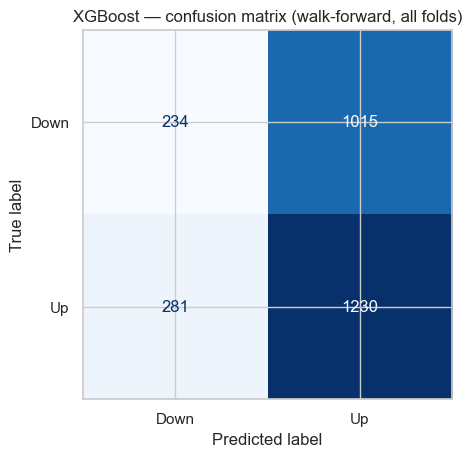

Predicted 'Up' share: 0.813
Actual    'Up' share: 0.547


In [8]:
# Collect predictions across all folds, then build one confusion matrix over everything
y_true_all, y_pred_all = [], []
for train_idx, test_idx in tscv.split(X):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
    y_tr_cls = (y_tr > 0).astype(int)
    y_te_cls = (y_te > 0).astype(int)
    m = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
    m.fit(X_tr, y_tr_cls)
    y_true_all.extend(y_te_cls.tolist())
    y_pred_all.extend(m.predict(X_te).tolist())

cm = confusion_matrix(y_true_all, y_pred_all)
ConfusionMatrixDisplay(cm, display_labels=["Down", "Up"]).plot(cmap="Blues", colorbar=False)
plt.title("XGBoost — confusion matrix (walk-forward, all folds)")
plt.show()

# Compare how often the model says "up" vs how often "up" actually happens — reveals if it just defaults to the majority class
print("Predicted 'Up' share:", round(sum(y_pred_all) / len(y_pred_all), 3))
print("Actual    'Up' share:", round(sum(y_true_all) / len(y_true_all), 3))

The "Down" column is almost empty — the model rarely predicts a down day.
Its predicted "up" share is far higher than the actual one, meaning it mostly defaults to the majority class instead of detecting direction. That's why its ~53% accuracy isn't skill: it's just copying the class distribution.

## Hyperparameter tuning with Optuna (LightGBM)

Optuna searches the hyperparameter space, with every trial logged to MLflow as a nested run.
**Key choice:** we optimize `accuracy − baseline` (the edge over "always up"), not raw accuracy — otherwise Optuna would "win" by landing on folds with a high up-share, rewarding luck instead of skill. Each trial is scored on the full 5-fold walk-forward.

In [9]:
def lgbm_objective(trial):
    """One Optuna trial: evaluate a hyperparameter set on the full walk-forward.

    Returns the mean (accuracy − baseline) across folds — the metric Optuna maximizes.
    """
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 50, 400),
        learning_rate=trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        num_leaves=trial.suggest_int("num_leaves", 4, 64),
        max_depth=trial.suggest_int("max_depth", 2, 6),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        random_state=42,
        verbose=-1,
    )
    diffs = []
    for train_idx, test_idx in tscv.split(X):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
        y_tr_cls = (y_tr > 0).astype(int)
        y_te_cls = (y_te > 0).astype(int)
        m = lgb.LGBMClassifier(**params)
        m.fit(X_tr, y_tr_cls)
        # Edge over baseline, averaged across folds — what we actually care about
        diffs.append(accuracy_score(y_te_cls, m.predict(X_te)) - y_te_cls.mean())
    mean_diff = float(np.mean(diffs))

    # Log each trial as a nested run so the full search is browsable in MLflow
    with mlflow.start_run(run_name=f"lgbm_trial_{trial.number}", nested=True):
        mlflow.set_tag("model", "lightgbm_optuna")
        mlflow.log_params(params)
        mlflow.log_metric("mean_diff", mean_diff)
    return mean_diff

with mlflow.start_run(run_name="lgbm_optuna_study"):
    study_lgbm = optuna.create_study(direction="maximize")
    study_lgbm.optimize(lgbm_objective, n_trials=30)
    mlflow.log_params(study_lgbm.best_params)
    mlflow.log_metric("best_mean_diff", study_lgbm.best_value)

print("LGBM best mean_diff:", round(study_lgbm.best_value, 4))
print("LGBM best params:", study_lgbm.best_params)

[I 2026-06-19 21:02:19,852] A new study created in memory with name: no-name-5e2b709c-3279-422e-a8c0-512c11d11e55
[I 2026-06-19 21:02:21,158] Trial 0 finished with value: -0.03224637681159419 and parameters: {'n_estimators': 255, 'learning_rate': 0.2020251997548691, 'num_leaves': 47, 'max_depth': 4, 'subsample': 0.7161163374219139, 'colsample_bytree': 0.8149725525242852}. Best is trial 0 with value: -0.03224637681159419.
[I 2026-06-19 21:02:22,499] Trial 1 finished with value: -0.0028985507246376717 and parameters: {'n_estimators': 129, 'learning_rate': 0.0056137664848727375, 'num_leaves': 26, 'max_depth': 6, 'subsample': 0.7118395558371515, 'colsample_bytree': 0.7552793793347141}. Best is trial 1 with value: -0.0028985507246376717.
[I 2026-06-19 21:02:23,341] Trial 2 finished with value: -0.021376811594202884 and parameters: {'n_estimators': 395, 'learning_rate': 0.13476919444747573, 'num_leaves': 54, 'max_depth': 2, 'subsample': 0.8742483985257702, 'colsample_bytree': 0.8079069042267

LGBM best mean_diff: -0.0029
LGBM best params: {'n_estimators': 129, 'learning_rate': 0.0056137664848727375, 'num_leaves': 26, 'max_depth': 6, 'subsample': 0.7118395558371515, 'colsample_bytree': 0.7552793793347141}


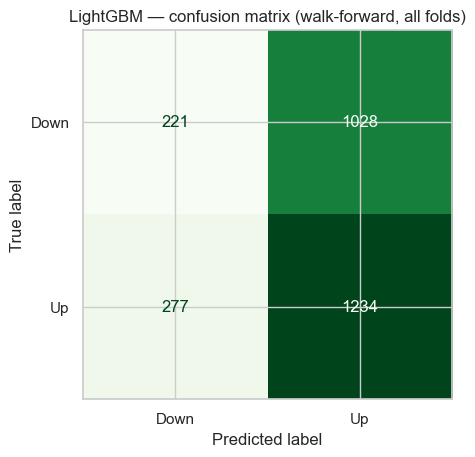

Predicted 'Up' share: 0.82
Actual    'Up' share: 0.547


In [10]:
# Collect predictions across all folds, then build one confusion matrix over everything
y_true_all, y_pred_all = [], []
for train_idx, test_idx in tscv.split(X):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
    y_tr_cls = (y_tr > 0).astype(int)
    y_te_cls = (y_te > 0).astype(int)
    m = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.05, num_leaves=8, max_depth=3, random_state=42, verbose=-1)
    m.fit(X_tr, y_tr_cls)
    y_true_all.extend(y_te_cls.tolist())
    y_pred_all.extend(m.predict(X_te).tolist())

cm = confusion_matrix(y_true_all, y_pred_all)
ConfusionMatrixDisplay(cm, display_labels=["Down", "Up"]).plot(cmap="Greens", colorbar=False)
plt.title("LightGBM — confusion matrix (walk-forward, all folds)")
plt.show()

# Same check as XGBoost: predicted vs actual "up" share
print("Predicted 'Up' share:", round(sum(y_pred_all) / len(y_pred_all), 3))
print("Actual    'Up' share:", round(sum(y_true_all) / len(y_true_all), 3))

Same behaviour as XGBoost: the model leans heavily toward predicting "up" and rarely calls a down day. Two independent libraries default to the majority class — further confirmation there's no directional signal to learn.

In [11]:
# Single-split reference for comparison with the walk-forward result above
# (one split = one number; walk-forward is the more reliable estimate)
y_train_cls = (y_train > 0).astype(int)
y_test_cls = (y_test > 0).astype(int)

model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
model.fit(X_train, y_train_cls)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test_cls, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.5309


In [12]:
# Single-split fit used for the prediction plot below (walk-forward gives metrics, not a single prediction series)
y_train_cls = (y_train > 0).astype(int)
y_test_cls = (y_test > 0).astype(int)

model = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.05, num_leaves=8, max_depth=3, random_state=42, verbose=-1)
model.fit(X_train, y_train_cls)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test_cls, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.5324


In [13]:
# Baseline: fraction of "up" days = accuracy you'd get by always predicting "up"
baseline_accuracy = y_test_cls.mean()
print(f"Accuracy (always up): {baseline_accuracy:.4f}")

Accuracy (always up): 0.5354


## Transformer (sequence model)

Unlike the tree models (which see one day at a time), the Transformer takes a **10-day window** of returns and predicts the next day.
Sequencing the data: each sample is 10 consecutive days of features, with the following day's SPY return as the target (later thresholded into up/down).

In [14]:
SEQ_LEN = 10  # number of past days the model sees at once

X_values = X.values
y_values = y.values

# Build sliding windows: each sample = SEQ_LEN consecutive days, target = the day right after the window
X_seq = []
y_seq = []
for i in range(len(X_values) - SEQ_LEN):
    window_X = X_values[i : i + SEQ_LEN]
    target_y = y_values[i + SEQ_LEN]
    X_seq.append(window_X)
    y_seq.append(target_y)

# Force a contiguous float32 array — otherwise torch.tensor() converts element-by-element and is very slow
X_seq = np.asarray(X_seq, dtype=np.float32)
y_seq = np.asarray(y_seq, dtype=np.float32)

# Same time-ordered split as before (no shuffling)
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq, y_seq,
    test_size=0.2,
    shuffle=False
)

In [15]:
class StockTransformer(nn.Module):
    """Transformer encoder for sequence prediction.

    Takes a window of SEQ_LEN days (each with `num_features` stock returns) and
    outputs a single value, later thresholded into an up/down decision.
    """

    def __init__(self, num_features, seq_len=SEQ_LEN, d_model=64, nhead=4, num_layers=2):
        """
        Args:
            num_features: number of input features per day (here: 12 stocks).
            seq_len: length of the input window (number of past days).
            d_model: internal embedding dimension.
            nhead: number of attention heads (must divide d_model).
            num_layers: number of stacked encoder layers.
        """
        super(StockTransformer, self).__init__()

        # Project the raw features of each day up to the model's embedding dimension
        self.input_layer = nn.Linear(num_features, d_model)

        # Learned positional encoding: without it, attention is order-agnostic and the
        # model couldn't tell day 1 from day 10 — essential for time-series data
        self.pos_embedding = nn.Parameter(torch.zeros(1, seq_len, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            batch_first=True,
            dim_feedforward=128,
            dropout=0.1
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Map the encoded sequence to a single output
        self.output_layer = nn.Linear(d_model, 1)

    def forward(self, x):
        """Run one forward pass; returns one value per sample."""
        x = self.input_layer(x)
        x = x + self.pos_embedding          # inject day-order information
        x = self.transformer_encoder(x)
        x = x[:, -1, :]                     # use the last day's representation as the summary
        out = self.output_layer(x)
        return out.squeeze()


num_features = X_train_seq.shape[2]
model = StockTransformer(num_features=num_features)
print(model)

StockTransformer(
  (input_layer): Linear(in_features=12, out_features=64, bias=True)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
)


In [16]:
# StandardScaler works on 2D data, but our sequences are 3D (samples, days, features).
# Flatten to 2D, scale, then reshape back to the original 3D shape.
samples_train, seq_len, features = X_train_seq.shape
X_train_2d = X_train_seq.reshape(-1, features)

samples_test, _, _ = X_test_seq.shape
X_test_2d = X_test_seq.reshape(-1, features)

# Fit on train only, apply to test — prevents test-set information leaking into scaling
scaler = StandardScaler()
X_train_scaled_2d = scaler.fit_transform(X_train_2d)
X_test_scaled_2d = scaler.transform(X_test_2d)

# Restore the (samples, days, features) shape the Transformer expects
X_train_seq_scaled = X_train_scaled_2d.reshape(samples_train, seq_len, features)
X_test_seq_scaled = X_test_scaled_2d.reshape(samples_test, seq_len, features)

In [17]:
BATCH_SIZE = 32

# Reproducibility: fix seeds so the Transformer gives the same result each run
torch.manual_seed(42)
np.random.seed(42)

# Tensors from the SCALED sequences; labels thresholded to up(1)/down(0)
X_train_t = torch.tensor(X_train_seq_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_seq_scaled, dtype=torch.float32)

y_train_seq_cls = (y_train_seq > 0).astype(np.float32)
y_test_seq_cls = (y_test_seq > 0).astype(np.float32)
y_train_t_cls = torch.tensor(y_train_seq_cls)
y_test_t_cls = torch.tensor(y_test_seq_cls)

train_dataset = TensorDataset(X_train_t, y_train_t_cls)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = TensorDataset(X_test_t, y_test_t_cls)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

model = StockTransformer(num_features=features)
criterion = nn.BCEWithLogitsLoss()   # combines sigmoid + binary cross-entropy; expects raw logits
optimizer = optim.Adam(model.parameters(), lr=0.0001)

EPOCHS = 8

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    correct_preds = 0
    total_preds = 0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X).squeeze()
        targets = batch_y.float().squeeze()

        loss = criterion(predictions, targets)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # logit > 0 ⇔ probability > 0.5 ⇔ predicted "up"
        predicted_classes = (predictions > 0).float()
        correct_preds += (predicted_classes == targets).sum().item()
        total_preds += targets.size(0)

    avg_loss = epoch_loss / len(train_loader)
    epoch_acc = correct_preds / total_preds

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch + 1}/{EPOCHS}] | Accuracy: {epoch_acc:.4f}")

model.eval()
correct_preds_test = 0
total_preds_test = 0

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        predictions = model(batch_X).squeeze()
        targets = batch_y.float().squeeze()
        predicted_classes = (predictions > 0).float()
        correct_preds_test += (predicted_classes == targets).sum().item()
        total_preds_test += targets.size(0)

test_accuracy = correct_preds_test / total_preds_test
print(f"Final Test Accuracy: {test_accuracy:.4f}")

Epoch [1/8] | Accuracy: 0.5210
Epoch [5/8] | Accuracy: 0.5452
Final Test Accuracy: 0.5401


### Transformer — Optuna tuning

Same nested-run setup as the tree models: each trial is scored on the full walk-forward and logged to MLflow.
Fewer trials here (10) because every trial trains 5 models. Tuning `d_model`, `nhead`, `num_layers` and learning rate — but with no signal in the data, even the best configuration won't beat the baseline.

In [18]:
X_all = X.values
y_all = y.values


def transformer_objective(trial):
    """One Optuna trial for the Transformer: full walk-forward, returns mean edge over baseline."""
    EPOCHS = 8
    BATCH_SIZE = 32
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    d_model = trial.suggest_categorical("d_model", [32, 64])
    nhead = trial.suggest_categorical("nhead", [2, 4])   # must divide d_model — both options here do
    num_layers = trial.suggest_int("num_layers", 1, 3)

    diffs = []
    for train_idx, test_idx in tscv.split(X_all):
        # Scale and sequence inside each fold (fit on train part only — no leakage)
        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_all[train_idx])
        X_te_scaled = scaler.transform(X_all[test_idx])
        y_tr_raw, y_te_raw = y_all[train_idx], y_all[test_idx]

        def make_seq(Xv, yv):
            """Turn a 2D returns array into (window, next-day-target) pairs of length SEQ_LEN."""
            Xs, ys = [], []
            for i in range(len(Xv) - SEQ_LEN):
                Xs.append(Xv[i:i+SEQ_LEN]); ys.append(yv[i+SEQ_LEN])
            return np.asarray(Xs, dtype=np.float32), np.asarray(ys, dtype=np.float32)

        X_tr_seq, y_tr_seq = make_seq(X_tr_scaled, y_tr_raw)
        X_te_seq, y_te_seq = make_seq(X_te_scaled, y_te_raw)
        y_tr_cls = (y_tr_seq > 0).astype(np.float32)
        y_te_cls = (y_te_seq > 0).astype(np.float32)

        tr_loader = DataLoader(TensorDataset(
            torch.tensor(X_tr_seq), torch.tensor(y_tr_cls)), batch_size=BATCH_SIZE, shuffle=False)

        # Fresh model each fold so it doesn't carry over learning from earlier periods
        model = StockTransformer(num_features=X_tr_seq.shape[2], d_model=d_model, nhead=nhead, num_layers=num_layers)
        criterion = nn.BCEWithLogitsLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)
        model.train()
        for _ in range(EPOCHS):
            for bx, by in tr_loader:
                optimizer.zero_grad()
                loss = criterion(model(bx).squeeze(), by.float().squeeze())
                loss.backward(); optimizer.step()

        model.eval()
        with torch.no_grad():
            pred_cls = (model(torch.tensor(X_te_seq)).squeeze() > 0).float().numpy()
        diffs.append(accuracy_score(y_te_cls, pred_cls) - y_te_cls.mean())

    mean_diff = float(np.mean(diffs))
    with mlflow.start_run(run_name=f"transformer_trial_{trial.number}", nested=True):
        mlflow.set_tag("model", "transformer_optuna")
        mlflow.log_params(dict(lr=lr, d_model=d_model, nhead=nhead, num_layers=num_layers, epochs=EPOCHS))
        mlflow.log_metric("mean_diff", mean_diff)
    return mean_diff

with mlflow.start_run(run_name="transformer_optuna_study"):
    study_tf = optuna.create_study(direction="maximize")
    study_tf.optimize(transformer_objective, n_trials=10)

[I 2026-06-19 21:02:54,090] A new study created in memory with name: no-name-528ab7a8-0018-431c-99b2-6ea1a5db5cb7
[I 2026-06-19 21:02:57,383] Trial 0 finished with value: -0.015129161067306995 and parameters: {'lr': 0.0006057298914207605, 'd_model': 64, 'nhead': 2, 'num_layers': 1}. Best is trial 0 with value: -0.015129161067306995.
[I 2026-06-19 21:03:01,015] Trial 1 finished with value: -0.019188201054930687 and parameters: {'lr': 0.004019415994194168, 'd_model': 32, 'nhead': 4, 'num_layers': 1}. Best is trial 0 with value: -0.015129161067306995.
[I 2026-06-19 21:03:10,818] Trial 2 finished with value: -0.03247232362627983 and parameters: {'lr': 0.004904597941643699, 'd_model': 32, 'nhead': 4, 'num_layers': 3}. Best is trial 0 with value: -0.015129161067306995.
[I 2026-06-19 21:03:16,016] Trial 3 finished with value: -0.016236167401075363 and parameters: {'lr': 0.003975122049065685, 'd_model': 32, 'nhead': 2, 'num_layers': 2}. Best is trial 0 with value: -0.015129161067306995.
[I 202

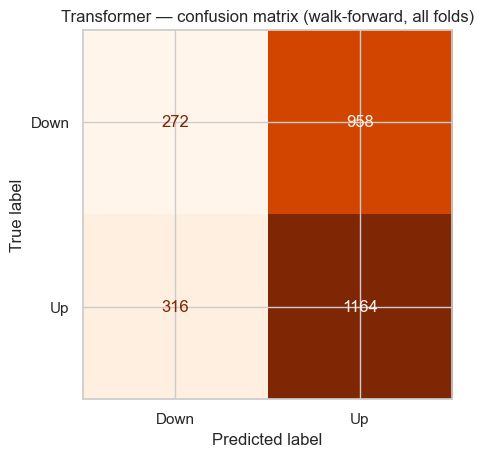

Predicted 'Up' share: 0.783
Actual    'Up' share: 0.546


In [19]:
# Confusion matrix for the Transformer, aggregated across all walk-forward folds
y_true_all, y_pred_all = [], []
for train_idx, test_idx in tscv.split(X_all):
    # Scale and sequence inside each fold (fit on train part only — no leakage)
    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_all[train_idx])
    X_te_scaled = scaler.transform(X_all[test_idx])
    y_tr_raw, y_te_raw = y_all[train_idx], y_all[test_idx]

    def make_seq(Xv, yv):
        """Turn a 2D returns array into (window, next-day-target) pairs of length SEQ_LEN."""
        Xs, ys = [], []
        for i in range(len(Xv) - SEQ_LEN):
            Xs.append(Xv[i:i+SEQ_LEN]); ys.append(yv[i+SEQ_LEN])
        return np.asarray(Xs, dtype=np.float32), np.asarray(ys, dtype=np.float32)

    X_tr_seq, y_tr_seq = make_seq(X_tr_scaled, y_tr_raw)
    X_te_seq, y_te_seq = make_seq(X_te_scaled, y_te_raw)
    y_tr_cls = (y_tr_seq > 0).astype(np.float32)
    y_te_cls = (y_te_seq > 0).astype(np.float32)

    tr_loader = DataLoader(TensorDataset(
        torch.tensor(X_tr_seq), torch.tensor(y_tr_cls)), batch_size=32, shuffle=False)

    # Fresh model each fold so it doesn't carry over learning from earlier periods
    model = StockTransformer(num_features=X_tr_seq.shape[2])
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    model.train()
    for _ in range(15):
        for bx, by in tr_loader:
            optimizer.zero_grad()
            loss = criterion(model(bx).squeeze(), by.float().squeeze())
            loss.backward(); optimizer.step()

    model.eval()
    with torch.no_grad():
        pred_cls = (model(torch.tensor(X_te_seq)).squeeze() > 0).float().numpy()  # logit > 0 ⇒ "up"

    y_true_all.extend(y_te_cls.tolist())
    y_pred_all.extend(pred_cls.tolist())

cm = confusion_matrix(y_true_all, y_pred_all)
ConfusionMatrixDisplay(cm, display_labels=["Down", "Up"]).plot(cmap="Oranges", colorbar=False)
plt.title("Transformer — confusion matrix (walk-forward, all folds)")
plt.show()

print("Predicted 'Up' share:", round(sum(y_pred_all) / len(y_pred_all), 3))
print("Actual    'Up' share:", round(sum(y_true_all) / len(y_true_all), 3))

The Transformer spreads its predictions a bit more than the trees, but still without real directional skill — the up/down split roughly mirrors the class balance rather than tracking actual moves.

## Conclusion

Across all three models, 5-fold walk-forward, and Optuna tuning, **none beats the "always up" baseline** by a meaningful margin — fold-to-fold differences hover around zero and the best tuned result is well within noise (std ≈ 10× the mean edge).
The confusion matrices show why: the models mostly default to the majority class instead of detecting direction.
Next-day SPY direction is not predictable from same-day constituent returns — consistent with weak-form market efficiency. The limitation is the data, not the models or their hyperparameters.

---
# Part 4 — Stock Selection with ARIMA, GARCH & LightGBM

Monthly walk-forward strategy: for each rebalance date, ARIMA(1,0,1) and GARCH(1,1) forecasts are used alongside momentum and MA-distance features to train a LightGBM classifier that ranks stocks by their probability of outperforming SPY. The top-3 picks are held until the next rebalance. A second model without ARIMA/GARCH (momentum-only features) is then compared, and MLflow run results are retrieved for both.

In [52]:
# imports
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model
import mlflow
import mlflow.lightgbm
import warnings
import shap
from mlflow.tracking import MlflowClient
from pathlib import Path

repo_root = Path.cwd().parent  # Add project root to sys.path
sys.path.insert(0, str(repo_root))

from src import utils

warnings.filterwarnings("ignore")


In [53]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")

### ARIMA + GARCH + LightGBM

2017-01-02 → ['JPM', 'GS', 'MS']
2017-02-01 → ['WFC', 'BAC', 'MS']
2017-03-03 → ['AAPL', 'BAC', 'MS']
2017-04-04 → ['NKE', 'MS', 'BAC']
2017-05-04 → ['TSLA', 'MSFT', 'KO']
2017-06-05 → ['BAC', 'TSLA', 'GS']
2017-07-05 → ['MS', 'NVDA', 'BAC']
2017-08-04 → ['TSLA', 'MS', 'ORCL']
2017-09-05 → ['NVDA', 'TSLA', 'NKE']
2017-10-05 → ['ORCL', 'TSLA', 'NVDA']


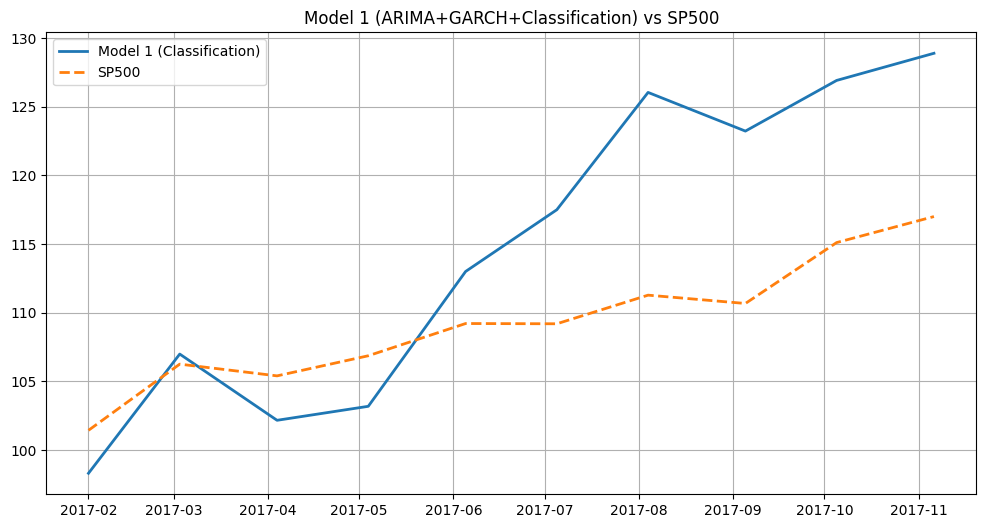

Final Alpha: 11.887254880075702


In [ ]:
# --- MLflow experiment ---
mlflow.set_experiment("Model_1_Classification_Backtest")

# --- Paths ---
etf_path = '/Users/marysia/Desktop/studia2/ml_project/Data_clean/ETF clean'
stocks_path = '/Users/marysia/Desktop/studia2/ml_project/Data_clean/Stocks clean'
spy_path = os.path.join(etf_path, 'spy_clean.csv')

sector_map = {
    'AAPL': 'XLK', 'MSFT': 'XLK', 'NVDA': 'XLK', 'AVGO': 'XLK', 'ORCL': 'XLK', 'ADBE': 'XLK',
    'LLY': 'XLV', 'JNJ': 'XLV', 'UNH': 'XLV', 'ABBV': 'XLV', 'MRK': 'XLV',
    'JPM': 'XLF', 'BAC': 'XLF', 'WFC': 'XLF', 'GS': 'XLF', 'MS': 'XLF',
    'GOOGL': 'XLC', 'META': 'XLC', 'NFLX': 'XLC', 'DIS': 'XLC',
    'AMZN': 'XLY', 'TSLA': 'XLY', 'HD': 'XLY', 'NKE': 'XLY',
    'PG': 'XLP', 'KO': 'XLP', 'PEP': 'XLP'
}

# --- Load data ---
def load_all_data():
    """
    Load SPY and selected stock data from CSV files.

    Returns
    -------
    spy : pandas.DataFrame
        DataFrame with SPY prices indexed by Date. Must contain at least 'Close'.
        A log return column 'Ret' is added: Ret = log(Close / Close.shift(1)).
    stock_dfs : dict
        Dictionary mapping ticker (str) -> pandas.DataFrame for each stock found in
        the stocks_path and listed in `sector_map`. Each DataFrame is indexed by Date,
        sorted, and contains a 'Ret' column with log returns.

    Notes
    -----
    - Expects files named like "<ticker>_clean.csv" (ticker lowercased) in stocks_path.
    - Parses dates using pandas.read_csv(..., parse_dates=True, index_col='Date').
    - Returns only tickers whose files exist on disk.
    """
    spy = pd.read_csv(spy_path, index_col='Date', parse_dates=True).sort_index()
    spy['Ret'] = np.log(spy['Close'] / spy['Close'].shift(1))

    stock_dfs = {}
    for ticker in sector_map.keys():
        f_path = os.path.join(stocks_path, f"{ticker.lower()}_clean.csv")
        if os.path.exists(f_path):
            df = pd.read_csv(f_path, index_col='Date', parse_dates=True).sort_index()
            df['Ret'] = np.log(df['Close'] / df['Close'].shift(1))
            stock_dfs[ticker] = df

    return spy, stock_dfs

df_spy, df_stocks = load_all_data()

# --- Feature extraction ---
def extract_features_for_date(date_point, horizon=22):
    """
    Compute ARIMA/GARCH and simple technical features for all stocks at a given date.

    Parameters
    ----------
    date_point : str or pandas.Timestamp
        Reference date (inclusive) used to cut historical data and compute features.
    horizon : int, optional
        Forecast horizon (in trading days) used to define the "future" period for
        the target and for checking enough data. Default is 22.

    Returns
    -------
    pandas.DataFrame or None
        DataFrame with one row per ticker containing:
        - Date, Ticker
        - feat_arima : float (ARIMA(1,0,1) 1-step forecast on last 20 returns)
        - feat_garch : float (GARCH(1,1) 1-step forecast volatility on last 60 returns)
        - feat_momentum : float (log return over last 20 closes)
        - feat_volatility : float (std of last 20 returns)
        - feat_dist_ma200 : float (distance to 200-day moving average; 0.0 if <200 days)
        - target : int (1 if stock outperforms SPY over horizon, else 0)

    Notes
    -----
    - Uses global variables df_spy and df_stocks.
    - Returns None when there is not enough historical or future data.
    - Exceptions in ARIMA/GARCH fitting are caught and replaced with fallback values.
    """
    features = []

    spy_cut = df_spy.loc[:date_point]
    if len(spy_cut) < 60:
        return None

    spy_future = df_spy.loc[date_point:].iloc[1:horizon+1]
    if len(spy_future) < horizon:
        return None

    spy_future_ret = np.log(spy_future['Close'].iloc[-1] / spy_cut['Close'].iloc[-1])

    for ticker, df in df_stocks.items():
        df_cut = df.loc[:date_point]
        df_future = df.loc[date_point:].iloc[1:horizon+1]

        if len(df_cut) < 60 or len(df_future) < horizon:
            continue

        rets20 = df_cut['Ret'].tail(20).dropna()
        rets60 = df_cut['Ret'].tail(60).dropna()

        # ARIMA
        try:
            m_arima = ARIMA(rets20, order=(1,0,1)).fit()
            feat_arima = m_arima.forecast(1).values[0]
        except:
            feat_arima = 0.0

        # GARCH
        try:
            m_garch = arch_model(rets60, vol='Garch', p=1, q=1, rescale=False).fit(disp='off')
            feat_garch = np.sqrt(m_garch.forecast(horizon=1).variance.values[-1][0])
        except:
            feat_garch = rets60.std()

        # Simple features
        mom20 = np.log(df_cut['Close'].iloc[-1] / df_cut['Close'].iloc[-20])
        vol20 = rets20.std()

        # MA200
        if len(df_cut) >= 200:
            ma200 = df_cut['Close'].rolling(200).mean().iloc[-1]
            dist_ma200 = (df_cut['Close'].iloc[-1] - ma200) / ma200
        else:
            dist_ma200 = 0.0

        # TARGET: outperform?
        stock_future_ret = np.log(df_future['Close'].iloc[-1] / df_cut['Close'].iloc[-1])
        target = int(stock_future_ret > spy_future_ret)

        features.append({
            'Date': date_point,
            'Ticker': ticker,
            'feat_arima': feat_arima,
            'feat_garch': feat_garch,
            'feat_momentum': mom20,
            'feat_volatility': vol20,
            'feat_dist_ma200': dist_ma200,
            'target': target
        })

    return pd.DataFrame(features) if features else None

# --- Walk-forward classification with MLflow ---
trading_days = df_spy.loc['2017-01-01':].index
rebalance_dates = [trading_days[i] for i in range(0, len(trading_days), 22)]

portfolio_returns = []
spy_returns = []
test_dates = []

with mlflow.start_run(run_name="Model_1_Classification_Backtest"):

    mlflow.log_param("model_type", "LightGBM Classification")
    mlflow.log_param("features", "ARIMA, GARCH, momentum20, volatility20, dist_MA200")
    mlflow.log_param("rebalance_frequency", "22 days")

    for step in range(len(rebalance_dates) - 1):
        current_date = rebalance_dates[step]
        next_date = rebalance_dates[step + 1]

        # Training set
        hist_dates = df_spy.loc[:current_date].index[-300::22]
        train_rows = []

        for d in hist_dates:
            df_feat = extract_features_for_date(d)
            if df_feat is not None:
                train_rows.append(df_feat)

        if not train_rows:
            continue

        df_train = pd.concat(train_rows, ignore_index=True)

        feature_cols = ['feat_arima', 'feat_garch', 'feat_momentum', 'feat_volatility', 'feat_dist_ma200']
        X_train = df_train[feature_cols]
        y_train = df_train['target']

        # Nested MLflow run
        with mlflow.start_run(nested=True, run_name=f"Step_{step}"):

            train_dataset = lgb.Dataset(X_train, label=y_train)
            params = {
                'objective': 'binary',
                'metric': 'binary_logloss',
                'learning_rate': 0.05,
                'max_depth': 4,
                'verbose': -1
            }

            model1 = lgb.train(params, train_dataset, num_boost_round=60)

            mlflow.lightgbm.log_model(model1, name=f"model_step_{step}")

            # Prediction
            df_test = extract_features_for_date(current_date)
            if df_test is None or df_test.empty:
                continue

            
            # --- sanity check: data leakage inspection ---
            train_dates = df_train['Date'].tolist()
            test_date = df_test['Date'].iloc[0]

            if utils.check_data_leakage(train_dates, test_date):
                raise RuntimeError(f"Data leakage detected for test date {test_date}")

            # Prediction continues
            X_test1 = df_test[feature_cols]
            df_test['prob'] = model1.predict(X_test1)

            top3 = df_test.sort_values(by='prob', ascending=False).head(3)
            tickers = top3['Ticker'].tolist()

            print(f"{current_date.date()} → {tickers}")

            # Returns
            spy_period = df_spy.loc[current_date:next_date]
            spy_ret = (spy_period['Close'].iloc[-1] / spy_period['Close'].iloc[0]) - 1
            spy_returns.append(spy_ret)

            stock_rets = []
            for t in tickers:
                s_df = df_stocks[t].loc[current_date:next_date]
                s_ret = (s_df['Close'].iloc[-1] / s_df['Close'].iloc[0]) - 1
                stock_rets.append(s_ret)

            portfolio_returns.append(np.mean(stock_rets))
            test_dates.append(next_date)

            # --- alpha for this step ---
            alpha_step = utils.calculate_forward_alpha(np.mean(stock_rets), spy_ret)
            mlflow.log_metric(f"alpha_step_{step}", alpha_step)

            # Final metrics
            cum_portfolio = np.cumprod(1 + np.array(portfolio_returns)) * 100
            cum_spy = np.cumprod(1 + np.array(spy_returns)) * 100

            final_alpha = (cum_portfolio[-1] - 100) - (cum_spy[-1] - 100)

            mlflow.log_metric("final_alpha", final_alpha)
            mlflow.log_metric("final_portfolio_return", cum_portfolio[-1])
            mlflow.log_metric("final_sp500_return", cum_spy[-1])

# --- Plot ---
plt.figure(figsize=(12,6))
plt.plot(test_dates, cum_portfolio, label="Model 1 (Classification)", lw=2)
plt.plot(test_dates, cum_spy, label="SP500", lw=2, ls='--')
plt.legend()
plt.grid(True)
plt.title("Model 1 (ARIMA+GARCH+Classification) vs SP500")
plt.show()

print("Final Alpha:", final_alpha)


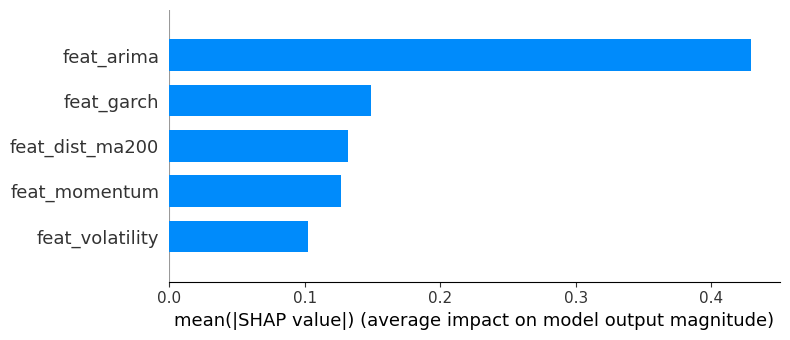

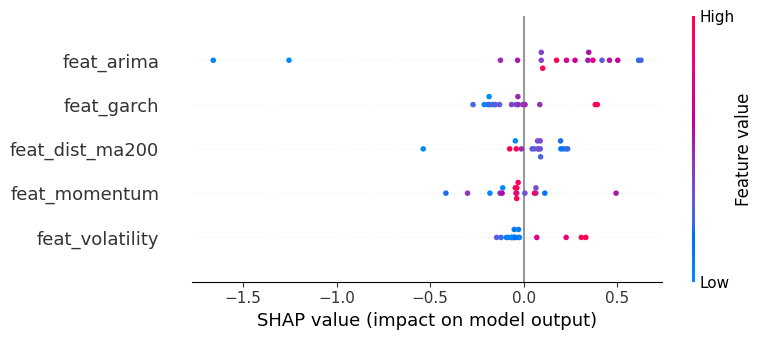

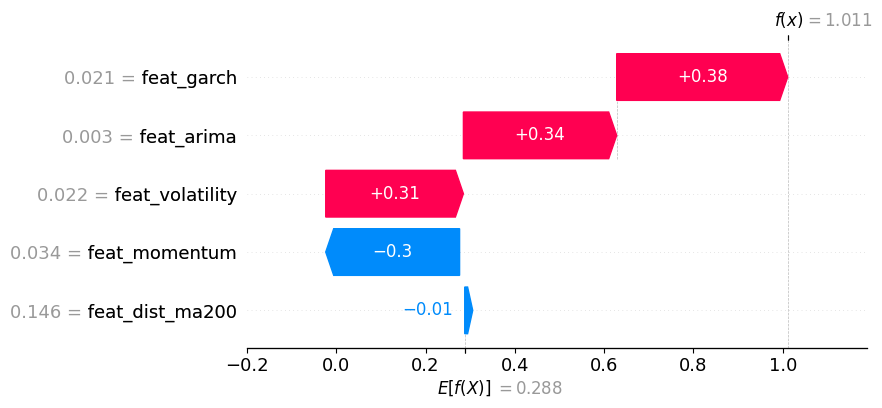

In [55]:
# --- pick the last walk-forward model ---
final_model1 = model1  # last model from walk-forward for model 1
final_X_test1 = X_test1  # X_test from last step of model 1

# --- SHAP TreeExplainer for model 1 ---
explainer1 = shap.TreeExplainer(final_model1)
shap_values1 = explainer1.shap_values(final_X_test1)

# --- Global importance (bar plot) ---
shap.summary_plot(shap_values1, final_X_test1, plot_type="bar")

# --- Beeswarm: feature effect direction ---
shap.summary_plot(shap_values1, final_X_test1)

# --- Waterfall for a single stock (e.g., TSLA) ---
i = df_test.index[df_test['Ticker'] == 'TSLA'][0]
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values1[i],
        base_values=explainer1.expected_value,
        data=final_X_test1.iloc[i],
        feature_names=final_X_test1.columns
    )
)

Model 1 - interpretation:

- The most important feature is ARIMA prediction about beating S&P500,
- GARCH volatility is the second-important feature (we can see that is far less iportant than ARIMA),
- distance to 200-day average, 20-day momentum  and (local) volatility have average influence on the model.

Scatter plot:

- If ARIMA gives high values, the probabilty of outperforming increases, low values affect the model negatively.
- GARCH works similarly, but affects the model less, mean values don't affect the model that much (bu slightly neagatively).
- High distance to MA200 gives slightly negative impact, but low values gives far more negative impact (see the blue dot on the left)
- Momentum doesn't behave so straightforward, because we see different colors on both sides of the ax.
- Local volatility - low values affect the model slightly negatively, high values affect positively.

Waterfall:
- $\mathbb{E}(f(X)) = 0.288$ is the base log-prediction of the model. For a chosed stock (`TSLA`) we showed a waterfall plot with the "thought process" of the model and how the value of $f$ changed with each component (feature):
    - the model adds first because of low distance to MA200
    - subtracts because of (poor) momentum 
    - ahen adds thanks to volatility,
    - adds thanks to ARIMA
    - adds thanks to GARCH 

    finishing with the final score $f = 1.011$ (we can calculate the probability using the formula $p = 1/ (a+ e^{-f(x)})$ if we want).

### new model, without ARIMA or GARCH

In [56]:
def extract_features_2(date_point, horizon=22):
    """
    Compute momentum, volatility, relative and calendar features for each stock at a date.

    Parameters
    ----------
    date_point : str or pandas.Timestamp
        Reference (cut-off) date for historical data.
    horizon : int, optional
        Number of trading days used to define the future window for the target.
        Default is 22.

    Returns
    -------
    pandas.DataFrame or None
        DataFrame with columns:
        - Date, Ticker
        - mom_5, mom_10, mom_20, mom_60 : sum of log returns over last X days
        - vol_20, vol_60 : std of returns over last X days
        - rel_mom_20_spy, rel_mom_60_spy : momentum relative to SPY
        - rel_mom_20_sector, rel_mom_60_sector : momentum relative to sector ETF (NaN if not available)
        - vol_rel_20, vol_rel_60 : volume last / mean volume over X days
        - day_of_week, month, is_month_end, is_quarter_end : calendar features
        - target : int (1 if future stock return > future SPY return over horizon)

    Notes
    -----
    - Uses global df_spy, df_stocks and sector_map; reads sector ETF files when available.
    - Returns None if there is insufficient historical or future data.
    - Volume-based features assume 'Volume' column exists in stock CSVs.
    """
    features = []

    spy_cut = df_spy.loc[:date_point]
    if len(spy_cut) < 120:
        return None

    spy_future = df_spy.loc[date_point:].iloc[1:horizon+1]
    if len(spy_future) < horizon:
        return None

    spy_future_ret = np.log(spy_future['Close'].iloc[-1] / spy_cut['Close'].iloc[-1])
    spy_rets = spy_cut['Ret'].dropna()

    if len(spy_rets) < 60:
        return None

    spy_mom_20 = spy_rets.tail(20).sum()
    spy_mom_60 = spy_rets.tail(60).sum()

    for ticker, df in df_stocks.items():
        df_cut = df.loc[:date_point]
        df_future = df.loc[date_point:].iloc[1:horizon+1]

        if len(df_cut) < 120 or len(df_future) < horizon:
            continue

        rets = df_cut['Ret'].dropna()
        if len(rets) < 60:
            continue

        # Momentum
        mom_5 = rets.tail(5).sum()
        mom_10 = rets.tail(10).sum()
        mom_20 = rets.tail(20).sum()
        mom_60 = rets.tail(60).sum()

        # Volatility
        vol_20 = rets.tail(20).std()
        vol_60 = rets.tail(60).std()

        # Relative to SPY
        rel_mom_20_spy = mom_20 - spy_mom_20
        rel_mom_60_spy = mom_60 - spy_mom_60

        # Relative to sector
        sector_ticker = sector_map.get(ticker, None)
        sec_mom_20 = np.nan
        sec_mom_60 = np.nan

        if sector_ticker:
            sec_path = os.path.join(etf_path, f"{sector_ticker.lower()}_clean.csv")
            if os.path.exists(sec_path):
                df_sec = pd.read_csv(sec_path, index_col='Date', parse_dates=True).sort_index()
                df_sec['Ret'] = np.log(df_sec['Close'] / df_sec['Close'].shift(1))
                sec_rets = df_sec.loc[:date_point]['Ret'].dropna()
                if len(sec_rets) >= 60:
                    sec_mom_20 = sec_rets.tail(20).sum()
                    sec_mom_60 = sec_rets.tail(60).sum()

        rel_mom_20_sector = mom_20 - sec_mom_20 if not np.isnan(sec_mom_20) else np.nan
        rel_mom_60_sector = mom_60 - sec_mom_60 if not np.isnan(sec_mom_60) else np.nan

        # Volume
        vol_series = df_cut['Volume'].dropna()
        if len(vol_series) < 60:
            continue

        vol_mean_20 = vol_series.tail(20).mean()
        vol_mean_60 = vol_series.tail(60).mean()
        vol_last = vol_series.iloc[-1]

        vol_rel_20 = vol_last / vol_mean_20 if vol_mean_20 > 0 else 1.0
        vol_rel_60 = vol_last / vol_mean_60 if vol_mean_60 > 0 else 1.0

        # Calendar
        d = pd.Timestamp(date_point)
        day_of_week = d.weekday()
        month = d.month
        is_month_end = int(d.is_month_end)
        is_quarter_end = int(d.is_quarter_end)

        # Target
        stock_future_ret = np.log(df_future['Close'].iloc[-1] / df_cut['Close'].iloc[-1])
        target = int(stock_future_ret > spy_future_ret)

        features.append({
            'Date': date_point,
            'Ticker': ticker,
            'mom_5': mom_5,
            'mom_10': mom_10,
            'mom_20': mom_20,
            'mom_60': mom_60,
            'vol_20': vol_20,
            'vol_60': vol_60,
            'rel_mom_20_spy': rel_mom_20_spy,
            'rel_mom_60_spy': rel_mom_60_spy,
            'rel_mom_20_sector': rel_mom_20_sector,
            'rel_mom_60_sector': rel_mom_60_sector,
            'vol_rel_20': vol_rel_20,
            'vol_rel_60': vol_rel_60,
            'day_of_week': day_of_week,
            'month': month,
            'is_month_end': is_month_end,
            'is_quarter_end': is_quarter_end,
            'target': target
        })

    return pd.DataFrame(features) if features else None


In [57]:
feature_cols = [
    'mom_5', 'mom_10', 'mom_20', 'mom_60',
    'vol_20', 'vol_60',
    'rel_mom_20_spy', 'rel_mom_60_spy',
    'rel_mom_20_sector', 'rel_mom_60_sector',
    'vol_rel_20', 'vol_rel_60',
    'day_of_week', 'month', 'is_month_end', 'is_quarter_end'
]

trading_days_new = df_spy.loc['2017-01-01':].index
rebalance_dates = [trading_days_new[i] for i in range(0, len(trading_days_new), 22)]

portfolio_returns2 = []
spy_returns2 = []
test_dates2 = []

# --- MLflow experiment ---
mlflow.set_experiment("Model_2_Classification_Backtest")

# Start an MLflow run for Model 2 backtest
with mlflow.start_run(run_name="Model_2_Classification_Backtest"):

    mlflow.log_param("model_type", "LightGBM Classification")
    mlflow.log_param("features", "momentum, volatility, relative to SPY/sector, volume, calendar")
    mlflow.log_param("rebalance_frequency", "22 days")

    for step in range(len(rebalance_dates) - 1):
        current_date = rebalance_dates[step]
        next_date = rebalance_dates[step + 1]

        # Training set: last 300 days every 22 days
        hist_dates = df_spy.loc[:current_date].index[-300::22]

        train_data = []
        for d in hist_dates:
            df_feat = extract_features_2(d)
            if df_feat is not None:
                train_data.append(df_feat)

        if not train_data:
            continue

        df_train = pd.concat(train_data, ignore_index=True)

        # --- sanity check: data leakage inspection ---
        train_dates = df_train['Date'].tolist()

        X_train2 = df_train[feature_cols]
        y_train2 = df_train['target']

        # Nested MLflow run per rebalancing step
        with mlflow.start_run(nested=True, run_name=f"Step_{step}_Model2"):

            mlflow.log_param("step", step)
            mlflow.log_param("train_rows", len(df_train))
            mlflow.log_param("train_unique_dates", len(hist_dates))

            train_dataset = lgb.Dataset(X_train2, label=y_train2)

            params = {
                'objective': 'binary',
                'metric': 'binary_logloss',
                'learning_rate': 0.05,
                'max_depth': 4,
                'verbose': -1
            }

            mlflow.log_params({'learning_rate': params['learning_rate'], 'max_depth': params['max_depth'], 'num_boost_round': 80})

            model2 = lgb.train(params, train_dataset, num_boost_round=80)

            # Log the trained model artifact
            mlflow.lightgbm.log_model(model2, name=f"model2_step_{step}")

            # Test
            df_test = extract_features_2(current_date)
            if df_test is None or df_test.empty:
                continue
            
            test_date = df_test['Date'].iloc[0]
            if utils.check_data_leakage(train_dates, current_date):
                raise RuntimeError(f"Data leakage detected for test date {current_date}")

            X_test2 = df_test[feature_cols]
            df_test['prob'] = model2.predict(X_test2)

            top3_ = df_test.sort_values(by='prob', ascending=False).head(3)
            tickers_ = top3_['Ticker'].tolist()

            print(f"{current_date.date()} → {tickers_}")

            # Returns
            spy_period = df_spy.loc[current_date:next_date]
            spy_ret = (spy_period['Close'].iloc[-1] / spy_period['Close'].iloc[0]) - 1
            spy_returns2.append(spy_ret)

            stock_rets = []
            for t in tickers_:
                s_df = df_stocks[t].loc[current_date:next_date]
                s_ret = (s_df['Close'].iloc[-1] / s_df['Close'].iloc[0]) - 1
                stock_rets.append(s_ret)

            step_port_return = np.mean(stock_rets)
            portfolio_returns2.append(step_port_return)
            test_dates2.append(next_date)

            alpha = utils.calculate_forward_alpha(np.mean(stock_rets), spy_ret)
            mlflow.log_metric(f"alpha_step{step}", alpha)

            # Log per-step metrics to MLflow (use step index for plotting consistency)
            mlflow.log_metric(f"step_portfolio_return{step}", float(step_port_return), step=step)
            mlflow.log_metric(f"step_spy_return{step}", float(spy_ret), step=step)
            mlflow.log_param(f"selected_tickers_step_{step}", ",".join(tickers_))

    # Final metrics for Model 2
    if portfolio_returns2:
        cum_portfolio2 = np.cumprod(1 + np.array(portfolio_returns2)) * 100
        cum_spy2 = np.cumprod(1 + np.array(spy_returns2)) * 100

        final_alpha2 = (cum_portfolio2[-1] - 100) - (cum_spy2[-1] - 100)

        mlflow.log_metric("final_alpha_model2", float(final_alpha2))
        mlflow.log_metric("final_portfolio_return_model2", float(cum_portfolio2[-1]))
        mlflow.log_metric("final_sp500_return_model2", float(cum_spy2[-1]))

2017-01-02 → ['ORCL', 'AMZN', 'MSFT']
2017-02-01 → ['WFC', 'AAPL', 'NVDA']
2017-03-03 → ['JNJ', 'NVDA', 'AAPL']
2017-04-04 → ['GS', 'PEP', 'WFC']
2017-05-04 → ['MRK', 'AAPL', 'GS']
2017-06-05 → ['TSLA', 'BAC', 'WFC']
2017-07-05 → ['NVDA', 'TSLA', 'GOOGL']
2017-08-04 → ['WFC', 'BAC', 'NVDA']
2017-09-05 → ['TSLA', 'NVDA', 'MSFT']
2017-10-05 → ['ABBV', 'MRK', 'NVDA']


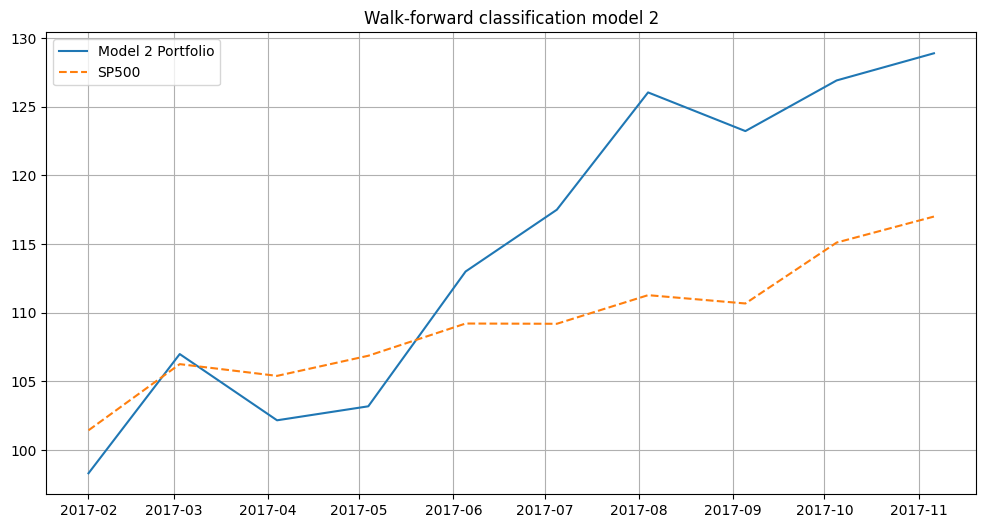

In [58]:
cum_portfolio_new = np.cumprod(1 + np.array(portfolio_returns)) * 100
cum_spy = np.cumprod(1 + np.array(spy_returns)) * 100

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(test_dates, cum_portfolio_new, label="Model 2 Portfolio")
plt.plot(test_dates, cum_spy, label="SP500", linestyle='--')
plt.legend()
plt.grid(True)
plt.title("Walk-forward classification model 2")
plt.show()


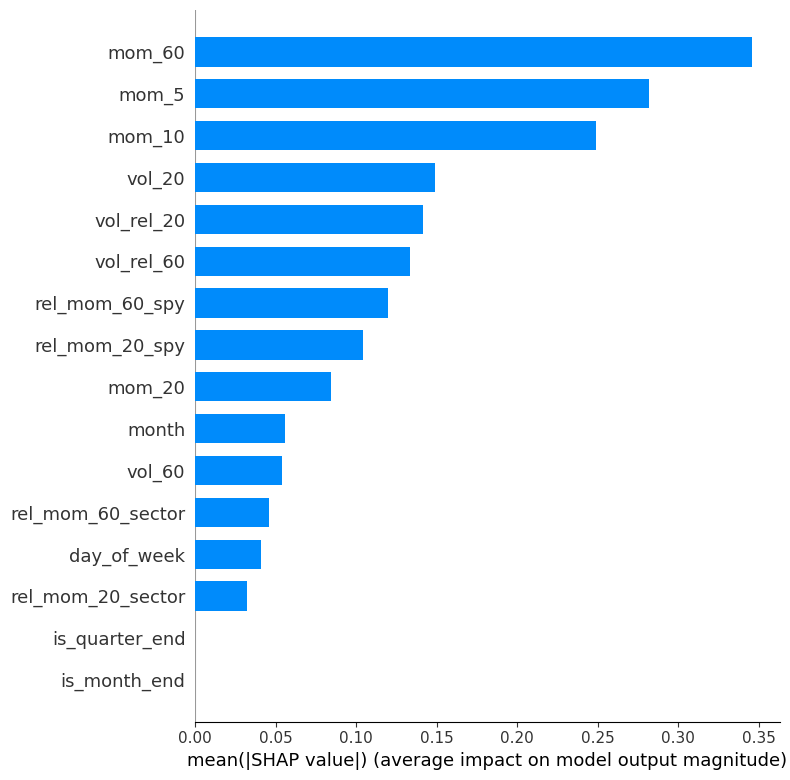

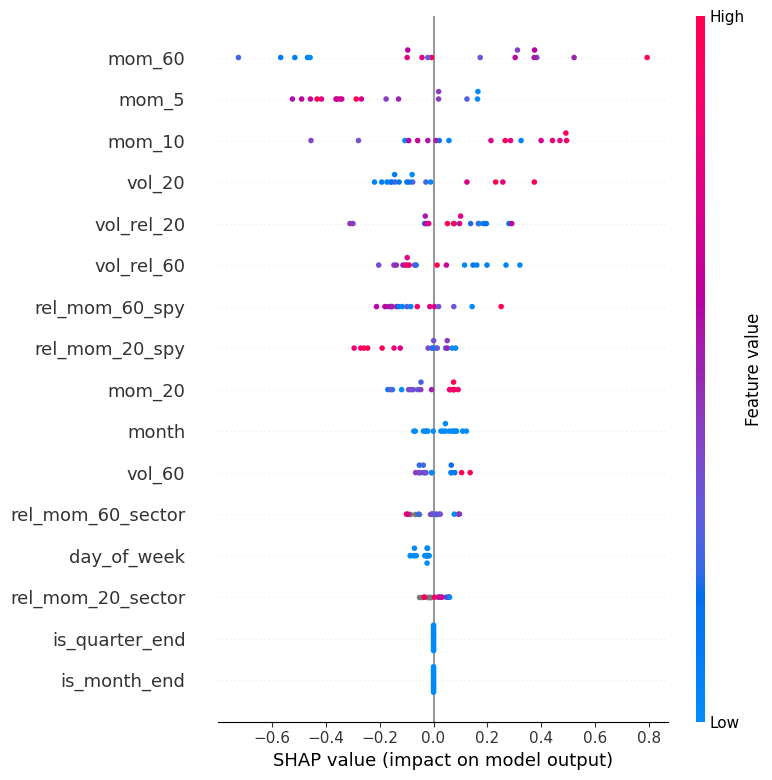

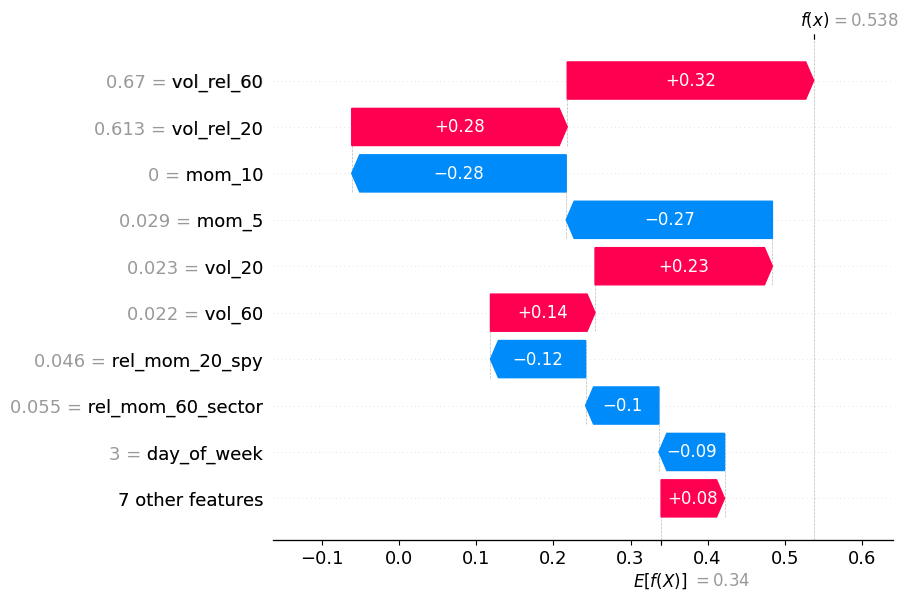

In [59]:
# --- wybieramy ostatni model z walk-forward ---
final_model2 = model2  # model z ostatniego kroku
final_X_test2 = X_test2  # X_test z ostatniego kroku

# --- SHAP TreeExplainer ---
explainer2 = shap.TreeExplainer(final_model2)
shap_values2 = explainer2.shap_values(final_X_test2)

# --- Global importance (bar plot) ---
shap.summary_plot(shap_values2, final_X_test2, plot_type="bar")

# --- Beeswarm: kierunek wpływu cech ---
shap.summary_plot(shap_values2, final_X_test2)

# --- Waterfall dla jednej spółki (np. pierwszej w X_test) ---
i = df_test.index[df_test['Ticker'] == 'NVDA'][0]
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values2[i],
        base_values=explainer2.expected_value,
        data=final_X_test2.iloc[i],
        feature_names=final_X_test2.columns
    )
)


In the second model, the most importatnt feature are momenta (60, 5 and 10 days) so, x-day returns. Less important features are: volatility (vol_20, which is he std over previous 20 days) and relative volatility (20, 60 days) - compared to our benchmark S&P500 (the difference in volatilities). The least important components are the rest of momenta, relative momenta, month (about 0.06 importance), day of the week and relative sector momenta (60 i 20).

From the scatterplot, we can see that for example low mom_60 (and other mom_x) gives us low probablility of beating the benchmark, but high values could either affect the model slightly into the negative side (-0.1:-0.05) or, very much into positive side (0.8). vol_20 generaly works linearly - low values affect negatively, high positively, whereas mom_5, vol_rel_60, rel_mom_60_spy seem to work the other way around.

Waterfall for 'NVDA' in the 2nd model shows us that volatility generally pushes model to give higher probability, and momenta (low values, slightly over 0) pushes to the other side. In this case, low values of each feature push the probability down, and high values push it up.

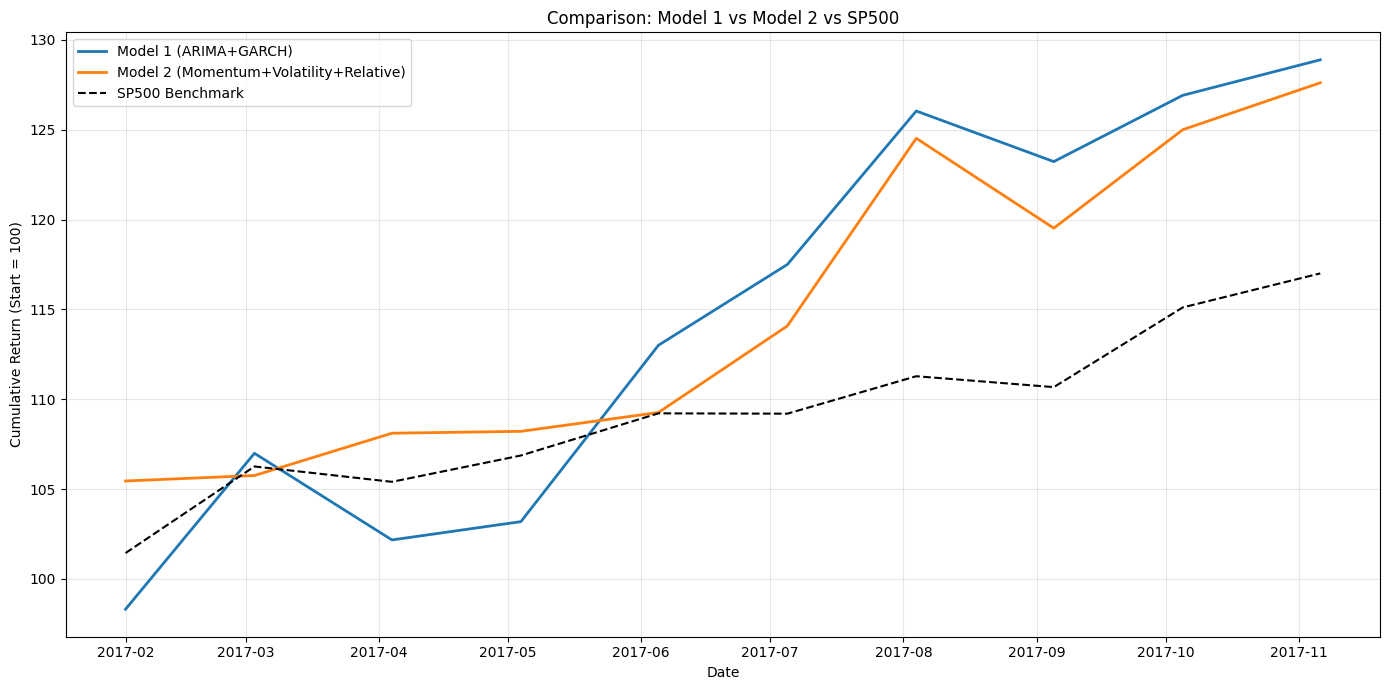

Model 1 Alpha: 11.887254880075702
Model 2 Alpha: 10.608466190294337
Difference (New - Old): -1.278788689781365


In [60]:
plt.figure(figsize=(14, 7))

plt.plot(test_dates, cum_portfolio, label="Model 1 (ARIMA+GARCH)", linewidth=2)
plt.plot(test_dates, cum_portfolio2, label="Model 2 (Momentum+Volatility+Relative)", linewidth=2)

plt.plot(test_dates, cum_spy, label="SP500 Benchmark", linestyle='--', color='black')

plt.title("Comparison: Model 1 vs Model 2 vs SP500")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (Start = 100)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

alpha_old = (cum_portfolio[-1] - 100) - (cum_spy[-1] - 100)
alpha_new = (cum_portfolio2[-1] - 100) - (cum_spy[-1] - 100)

print("Model 1 Alpha:", alpha_old)
print("Model 2 Alpha:", alpha_new)
print("Difference (New - Old):", alpha_new - alpha_old)


From the plot and comparing the alphas we can see that the 1st model is actually better than the 2nd one - it proves that ARIMA and GARCH are indeed importan features for this kind of data. On the other hand, ignoring them and using differen features (volatility, momentum) is still good enough.

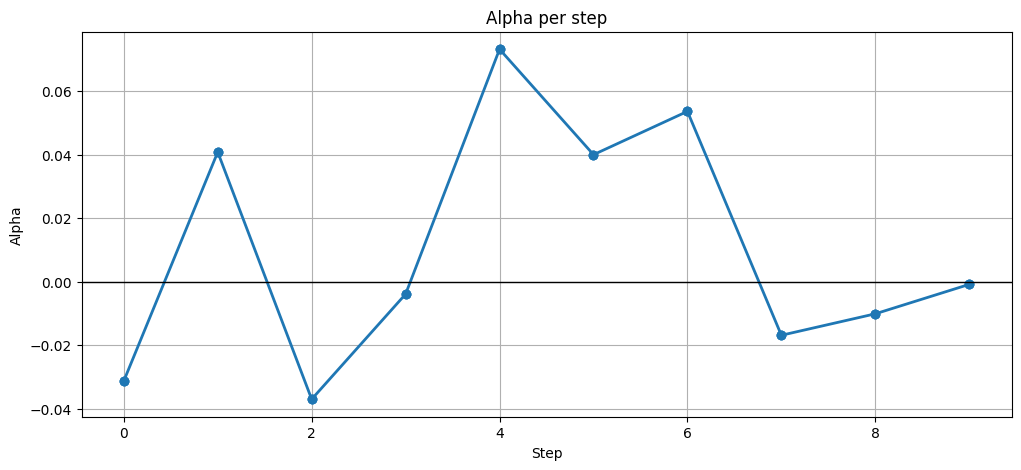

In [ ]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
client = MlflowClient()

exp = client.get_experiment_by_name("Model_1_Classification_Backtest")
runs = client.search_runs([exp.experiment_id])

rows = []

for r in runs:
    name = r.info.run_name
    metrics = r.data.metrics

    if name.startswith("Step_"):

        for k, v in metrics.items():
            if k.startswith("alpha_step_"):
                step = int(k.replace("alpha_step_", ""))
                rows.append({"step": step, "alpha": v})

df_alpha = pd.DataFrame(rows).sort_values("step")


plt.figure(figsize=(12,5))
plt.plot(df_alpha["step"], df_alpha["alpha"], marker="o", lw=2)
plt.axhline(0, color="black", lw=1)
plt.grid(True)
plt.title("Alpha per step")
plt.xlabel("Step")
plt.ylabel("Alpha")
plt.show()


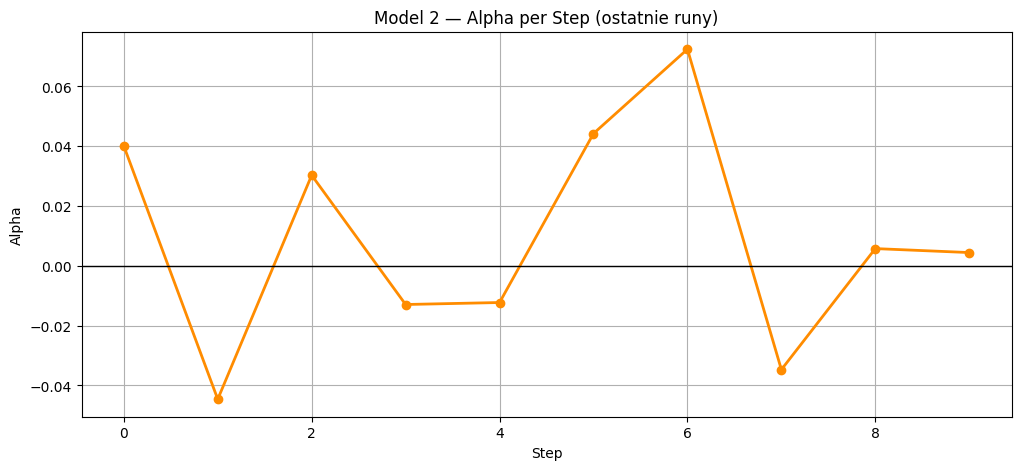

In [ ]:
client = MlflowClient()

exp = client.get_experiment_by_name("Model_2_Classification_Backtest")
runs = client.search_runs([exp.experiment_id])

rows = []

for r in runs:
    name = r.info.run_name
    if name.startswith("Step_") and "Model2" in name:
        metrics = r.data.metrics
        if "alpha_step" in metrics:
            step = int(name.split("_")[1])
            rows.append({
                "step": step,
                "alpha": metrics["alpha_step"],
                "start_time": r.info.start_time,
                "run_id": r.info.run_id,
            })

df = pd.DataFrame(rows)

df_latest = (
    df.sort_values("start_time")
      .groupby("step", as_index=False)
      .tail(1)          # latest run for each step
      .sort_values("step")
)

plt.figure(figsize=(12,5))
plt.plot(df_latest["step"], df_latest["alpha"], marker="o", lw=2, color="darkorange")
plt.axhline(0, color="black", lw=1)
plt.grid(True)
plt.title("Model 2 — Alpha per Step (last run for each step)")
plt.xlabel("Step")
plt.ylabel("Alpha")
plt.show()


---
# Part 5 — Neural Network Asset Allocation & Portfolio Risk Dashboard

A feed-forward neural network is trained to predict next-day asset returns for a 10-stock universe, then used to drive an active allocation strategy. Performance is benchmarked against a static Markowitz-optimised portfolio and SPY. The section closes with a GARCH-based risk dashboard and a Monte Carlo DCA simulator.

[*********************100%***********************]  11 of 11 completed


Initializing Baseline Portfolio (Markowitz Optimization)...

Training neural network on data before 2021-06-01...
Epoch [15/60] | Train MSE Loss: 1.2128
Epoch [30/60] | Train MSE Loss: 0.7242
Epoch [45/60] | Train MSE Loss: 0.5180
Epoch [60/60] | Train MSE Loss: 0.4606

Starting Active Trading Simulation (2021-06-01 to 2026-06-12)...

METRIC                    | ML PORTFOLIO    | S&P 500 (SPY)  
-----------------------------------------------------------------
Cumulative Return         |         125.41% |          88.06%
Annualized Return (CAGR)  |          17.59% |          13.42%
Annualized Volatility     |          14.94% |          17.07%
Sharpe Ratio              |           1.18  |           0.79 
Sortino Ratio             |           1.69  |           1.08 
Maximum Drawdown          |         -15.25% |         -24.50%
Daily Win Rate            |          54.75% |          54.51%

Generating Analytics Dashboard...


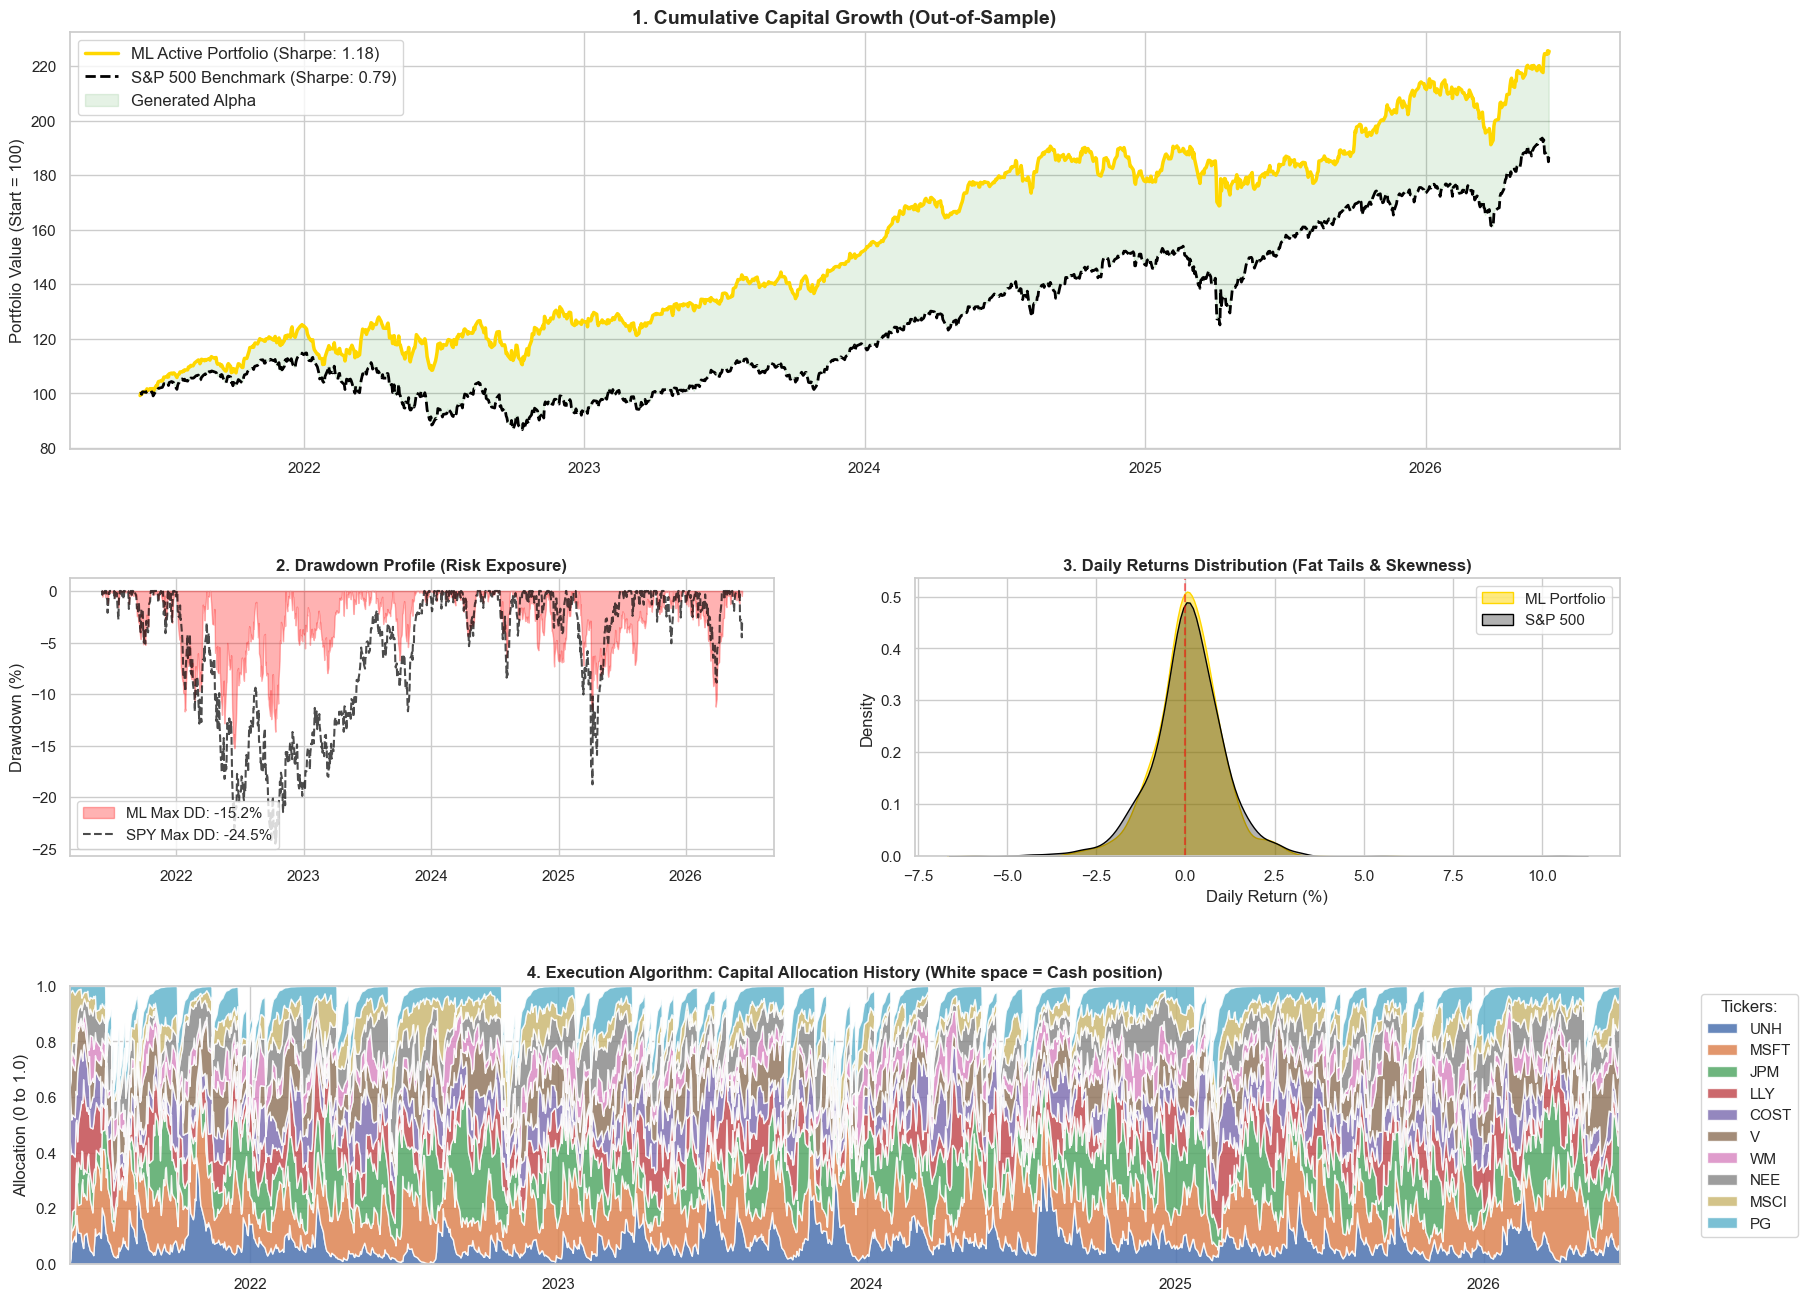

In [1]:
"""
Machine Learning Asset Allocation Simulator.

This script fetches historical stock data, trains a deep neural network to predict 
daily asset returns, and simulates an active trading strategy out-of-sample. 
The active strategy's performance is benchmarked against a static Markowitz 
Optimized portfolio and the S&P 500 (SPY).
"""

import warnings
from typing import List, Tuple

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import yfinance as yf
from pypfopt import EfficientFrontier, expected_returns, risk_models
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")


# =========================================================
# 0. CONFIGURATION & DATES
# =========================================================
TRAIN_START: str = "2020-01-01"
SIMULATION_START: str = "2021-06-01"
SIMULATION_END: str = "2026-06-12"

SEQ_LENGTH: int = 60
TICKERS: List[str] = [
    "UNH", "MSFT", "JPM", "LLY", "COST", 
    "V", "WM", "NEE", "MSCI", "PG"
]
NUM_ASSETS: int = len(TICKERS)


# =========================================================
# 1. DATA ACQUISITION & PREPARATION
# =========================================================
print(f"Downloading data from {TRAIN_START} to {SIMULATION_END}...")

# Fetch data and align indices to prevent dimension mismatches
raw_data = yf.download(
    TICKERS + ["SPY"], 
    start=TRAIN_START, 
    end=SIMULATION_END, 
    auto_adjust=True
)['Close'].dropna()

spy_prices = raw_data['SPY']
stock_prices = raw_data.drop(columns=['SPY'])

# Calculate daily returns and scale by 100 for percentage format
returns = stock_prices.pct_change().dropna() * 100
spy_returns = spy_prices.pct_change().dropna() * 100
returns, spy_returns = returns.align(spy_returns, join='inner', axis=0)


# =========================================================
# 2. INITIALIZE BASELINE PORTFOLIO (Markowitz Optimization)
# =========================================================
print("Initializing Baseline Portfolio (Markowitz Optimization)...")

# Isolate training data strictly to avoid data leakage during optimization
train_data_for_opt = stock_prices[:SIMULATION_START].iloc[:-1]

mu = expected_returns.mean_historical_return(train_data_for_opt)
S = risk_models.sample_cov(train_data_for_opt)
ef = EfficientFrontier(mu, S)

raw_weights = ef.max_sharpe()
cleaned_weights = ef.clean_weights()

# Create static weight vector for the baseline portfolio
static_weights = np.array([cleaned_weights.get(t, 0) for t in TICKERS])


# =========================================================
# 3. FEATURE ENGINEERING & TRAIN/TEST SPLIT
# =========================================================
scaler = StandardScaler()
# Scale returns and clip outliers to stabilize neural network training
scaled_returns = np.clip(scaler.fit_transform(returns.values), -3, 3)

xs: List[np.ndarray] = []
ys_future_ret: List[np.ndarray] = []
valid_dates = returns.index[SEQ_LENGTH:]

# Create sequential batches for training
for i in range(len(scaled_returns) - SEQ_LENGTH):
    xs.append(scaled_returns[i : i + SEQ_LENGTH])
    # Target: The actual return of each asset on day T+1
    ys_future_ret.append(returns.values[i + SEQ_LENGTH])

X = torch.tensor(np.array(xs), dtype=torch.float32)
Y_ret = torch.tensor(np.array(ys_future_ret), dtype=torch.float32)

# Create boolean masks based on the user-defined date parameters
train_mask = valid_dates < SIMULATION_START
test_mask = (valid_dates >= SIMULATION_START) & (valid_dates <= SIMULATION_END)

X_train, Y_train = X[train_mask], Y_ret[train_mask]
X_test, Y_test = X[test_mask], Y_ret[test_mask]

test_dates = valid_dates[test_mask]
spy_test_returns = spy_returns.values[SEQ_LENGTH:][test_mask]

train_loader = DataLoader(
    TensorDataset(X_train, Y_train), 
    batch_size=64, 
    shuffle=True
)


# =========================================================
# 4. NEURAL NETWORK ARCHITECTURE
# =========================================================
class AssetReturnPredictor(nn.Module):
    """
    Feed-forward Neural Network for predicting asset returns based on 
    historical sequential data.
    
    Args:
        num_assets (int): Number of distinct assets to predict.
        seq_length (int): Length of the look-back window (sequence length).
    """
    def __init__(self, num_assets: int, seq_length: int) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(num_assets * seq_length, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.01),
            nn.Linear(64, num_assets)
        )
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the neural network.
        
        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, seq_length, num_assets).
            
        Returns:
            torch.Tensor: Predicted next-day returns of shape (batch_size, num_assets).
        """
        return self.net(x.view(x.size(0), -1))


# =========================================================
# 5. MODEL TRAINING
# =========================================================
model = AssetReturnPredictor(num_assets=NUM_ASSETS, seq_length=SEQ_LENGTH)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
EPOCHS: int = 60

print(f"\nTraining neural network on data before {SIMULATION_START}...")
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(batch_x), batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    if (epoch + 1) % 15 == 0:
        avg_loss = epoch_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{EPOCHS}] | Train MSE Loss: {avg_loss:.4f}")


# =========================================================
# 6. TRADING SIMULATOR (Out-of-Sample)
# =========================================================
print(f"\nStarting Active Trading Simulation ({SIMULATION_START} to {SIMULATION_END})...")
model.eval()

# Start with the baseline optimized weights
current_ml_weights = np.copy(static_weights)
weights_history: List[np.ndarray] = []

ml_daily_returns_list: List[float] = []
static_daily_returns_list: List[float] = []
spy_daily_returns_list: List[float] = []

with torch.no_grad():
    for i in range(len(X_test)):
        # Predict tomorrow's return for each asset
        pred_returns = model(X_test[i:i+1]).numpy()[0]
        
        # Determine target portfolio allocation
        target_weights = np.zeros(NUM_ASSETS)
        positive_indices = pred_returns > 0
        
        # Only buy assets with a predicted positive return
        if np.any(positive_indices):
            target_weights[positive_indices] = (
                pred_returns[positive_indices] / np.sum(pred_returns[positive_indices])
            )

        # Smooth transition: 20% rebalancing per day to mitigate turnover/volatility
        current_ml_weights = 0.8 * current_ml_weights + 0.2 * target_weights
        weights_history.append(current_ml_weights)
        
        # Calculate actual portfolio returns for the day
        actual_daily_returns = Y_test[i].numpy() / 100.0
        
        ml_daily_returns_list.append(np.dot(current_ml_weights, actual_daily_returns))
        static_daily_returns_list.append(np.dot(static_weights, actual_daily_returns))
        spy_daily_returns_list.append(spy_test_returns[i] / 100.0)

# Convert outputs to pandas formats
ml_ret_series = pd.Series(ml_daily_returns_list, index=test_dates)
spy_ret_series = pd.Series(spy_daily_returns_list, index=test_dates)

# Cumulative capital trajectory (Base = 100)
ml_cum_returns = (1 + ml_ret_series).cumprod() * 100
spy_cum_returns = (1 + spy_ret_series).cumprod() * 100

df_weights = pd.DataFrame(weights_history, index=test_dates, columns=TICKERS)


# =========================================================
# 7. QUANTITATIVE METRICS & TEARSHEET
# =========================================================
def calculate_metrics(
    returns_series: pd.Series
) -> Tuple[float, float, float, float, float, float, float, pd.Series]:
    """
    Computes standard quantitative performance metrics for a return series.
    
    Args:
        returns_series (pd.Series): A pandas series of daily percentage returns.
        
    Returns:
        Tuple: Contains cumulative return, CAGR, annualized volatility, 
               Sharpe ratio, max drawdown, Sortino ratio, win rate, 
               and the drawdown time series.
    """
    cum_ret = (1 + returns_series).prod() - 1
    years = len(returns_series) / 252
    cagr = (1 + cum_ret) ** (1 / years) - 1 if years > 0 else 0
    
    volatility = returns_series.std() * np.sqrt(252)
    sharpe = cagr / volatility if volatility > 0 else 0
    
    roll_max = (1 + returns_series).cumprod().cummax()
    drawdown = ((1 + returns_series).cumprod() - roll_max) / roll_max
    max_dd = drawdown.min()
    
    downside_returns = returns_series[returns_series < 0]
    downside_vol = downside_returns.std() * np.sqrt(252)
    sortino = cagr / downside_vol if downside_vol > 0 else 0
    
    win_rate = (returns_series > 0).mean()
    
    return cum_ret, cagr, volatility, sharpe, max_dd, sortino, win_rate, drawdown


(ml_cum, ml_cagr, ml_vol, ml_sharpe, ml_mdd, ml_sortino, ml_win, ml_dd_series) = calculate_metrics(ml_ret_series)
(spy_cum, spy_cagr, spy_vol, spy_sharpe, spy_mdd, spy_sortino, spy_win, spy_dd_series) = calculate_metrics(spy_ret_series)

print("\n" + "="*65)
print(f"{'METRIC':<25} | {'ML PORTFOLIO':<15} | {'S&P 500 (SPY)':<15}")
print("-" * 65)
print(f"{'Cumulative Return':<25} | {ml_cum*100:>14.2f}% | {spy_cum*100:>14.2f}%")
print(f"{'Annualized Return (CAGR)':<25} | {ml_cagr*100:>14.2f}% | {spy_cagr*100:>14.2f}%")
print(f"{'Annualized Volatility':<25} | {ml_vol*100:>14.2f}% | {spy_vol*100:>14.2f}%")
print(f"{'Sharpe Ratio':<25} | {ml_sharpe:>14.2f}  | {spy_sharpe:>14.2f} ")
print(f"{'Sortino Ratio':<25} | {ml_sortino:>14.2f}  | {spy_sortino:>14.2f} ")
print(f"{'Maximum Drawdown':<25} | {ml_mdd*100:>14.2f}% | {spy_mdd*100:>14.2f}%")
print(f"{'Daily Win Rate':<25} | {ml_win*100:>14.2f}% | {spy_win*100:>14.2f}%")
print("="*65)


# =========================================================
# 8. VISUALIZATION DASHBOARD
# =========================================================
print("\nGenerating Analytics Dashboard...")
fig = plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(3, 2, height_ratios=[1.5, 1, 1], hspace=0.4, wspace=0.2)

# --- PLOT 1: Cumulative Equity Curve ---
ax0 = plt.subplot(gs[0, :])
ax0.plot(
    ml_cum_returns.index, ml_cum_returns, 
    color='gold', lw=2.5, 
    label=f'ML Active Portfolio (Sharpe: {ml_sharpe:.2f})'
)
ax0.plot(
    spy_cum_returns.index, spy_cum_returns, 
    color='black', linestyle='--', lw=2, 
    label=f'S&P 500 Benchmark (Sharpe: {spy_sharpe:.2f})'
)
ax0.set_title("1. Cumulative Capital Growth (Out-of-Sample)", fontweight='bold', fontsize=14)
ax0.set_ylabel("Portfolio Value (Start = 100)")
ax0.fill_between(
    ml_cum_returns.index, ml_cum_returns, spy_cum_returns, 
    where=(ml_cum_returns > spy_cum_returns), 
    interpolate=True, color='green', alpha=0.1, label='Generated Alpha'
)
ax0.legend(loc='upper left', fontsize=12)

# --- PLOT 2: Drawdown Profile ---
ax1 = plt.subplot(gs[1, 0])
ax1.fill_between(
    ml_dd_series.index, ml_dd_series * 100, 0, 
    color='red', alpha=0.3, label=f'ML Max DD: {ml_mdd*100:.1f}%'
)
ax1.plot(
    spy_dd_series.index, spy_dd_series * 100, 
    color='black', linestyle='--', alpha=0.7, 
    label=f'SPY Max DD: {spy_mdd*100:.1f}%'
)
ax1.set_title("2. Drawdown Profile (Risk Exposure)", fontweight='bold')
ax1.set_ylabel("Drawdown (%)")
ax1.legend(loc='lower left')

# --- PLOT 3: Daily Returns Distribution ---
ax2 = plt.subplot(gs[1, 1])
sns.kdeplot(
    ml_ret_series * 100, ax=ax2, 
    color='gold', fill=True, label='ML Portfolio', alpha=0.5
)
sns.kdeplot(
    spy_ret_series * 100, ax=ax2, 
    color='black', fill=True, label='S&P 500', alpha=0.3
)
ax2.axvline(0, color='red', linestyle='--', alpha=0.5)
ax2.set_title("3. Daily Returns Distribution (Fat Tails & Skewness)", fontweight='bold')
ax2.set_xlabel("Daily Return (%)")
ax2.set_ylabel("Density")
ax2.legend()

# --- PLOT 4: Dynamic Capital Allocation ---
ax3 = plt.subplot(gs[2, :])
ax3.stackplot(test_dates, df_weights.T, labels=TICKERS, alpha=0.85, cmap='tab10')
ax3.set_title(
    "4. Execution Algorithm: Capital Allocation History (White space = Cash position)", 
    fontweight='bold'
)
ax3.set_ylabel("Allocation (0 to 1.0)")
ax3.margins(x=0)
ax3.set_ylim(0, 1)
ax3.legend(loc='upper right', bbox_to_anchor=(1.12, 1), title="Tickers:")

plt.show()

[*********************100%***********************]  11 of 11 completed


Optimizing portfolio (Max Sharpe)...
Generating Portfolio Visualization Suite...


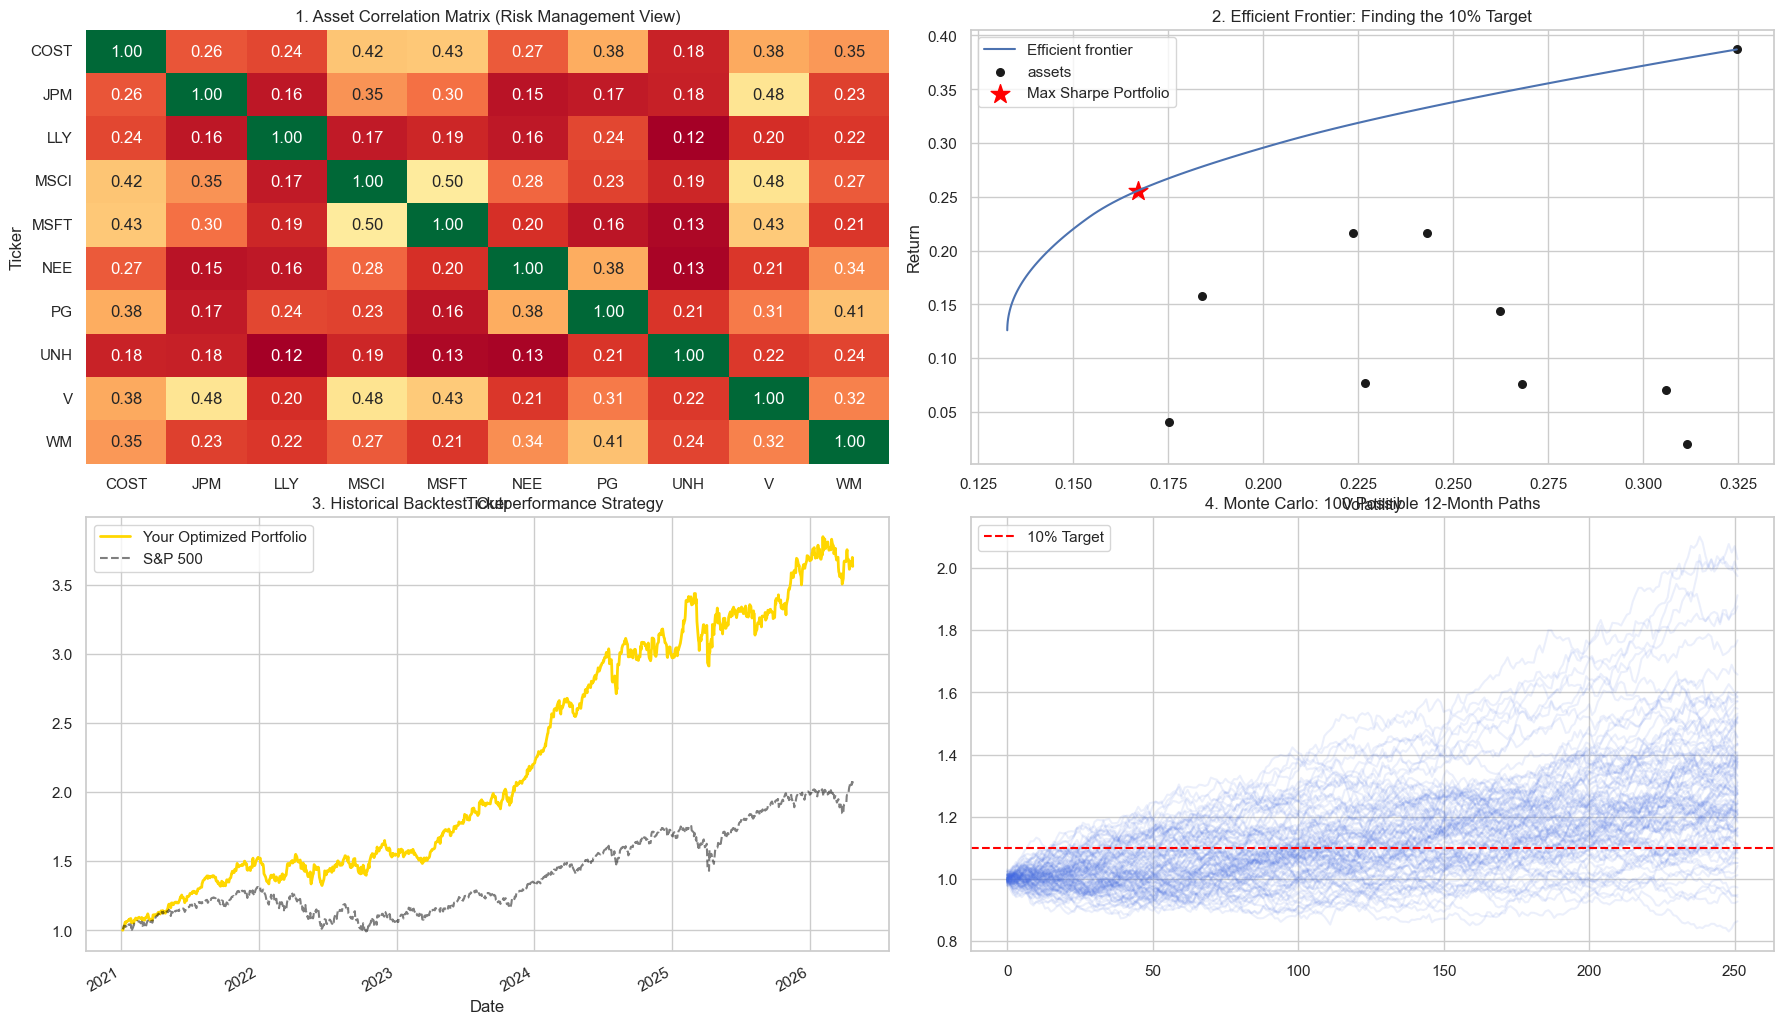


--- Running Prophet ML Forecast for Core Asset: MSFT ---


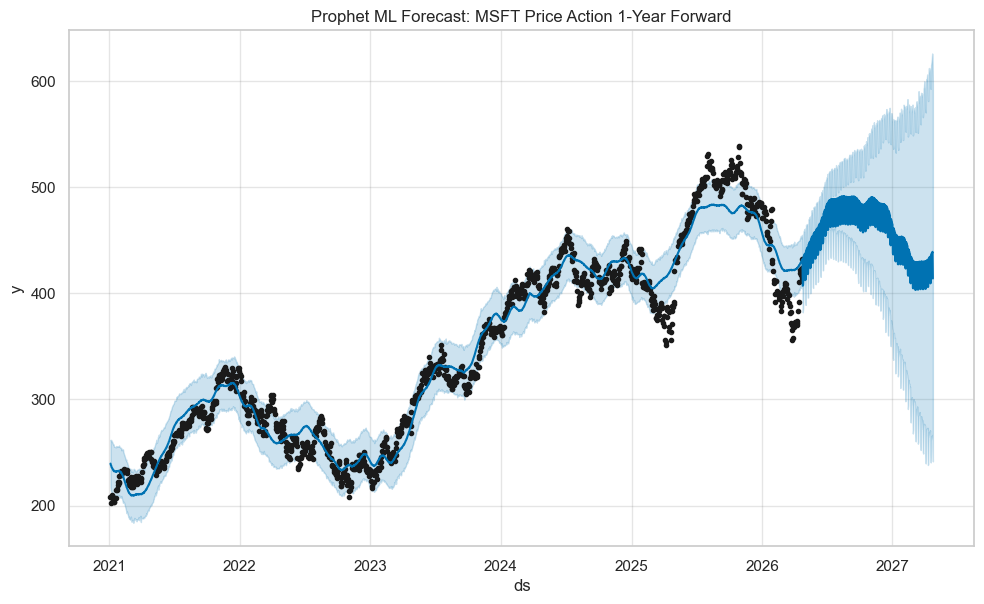


Ticker   | Weight (%)   | Monthly Target Allocation
------------------------------------------------------------
COST     |      23.34% | $            116.72
JPM      |      24.07% | $            120.38
LLY      |      30.63% | $            153.12
WM       |      21.95% | $            109.77

--- Modeling S&P 500 (SPY) using LSTM and tracking via MLflow ---
Starting LSTM network training...
Epoch [10/30], Loss: 0.003790
Epoch [20/30], Loss: 0.001042


2026/06/19 21:55:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/19 21:55:22 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


Epoch [30/30], Loss: 0.001698
Training completed. Final test error (MSE): 0.002514

[INFO] Logs and model weights saved to MLflow.
[INFO] To view the analytics dashboard, run 'mlflow ui' in your terminal.


In [2]:
"""
Advanced Quantitative Portfolio Manager & Forecasting Suite.

This script performs end-to-end financial data analysis by integrating Modern 
Portfolio Theory (PyPortfolioOpt) for asset allocation, Facebook Prophet for 
individual stock time-series forecasting, and a PyTorch LSTM neural network 
tracked via MLflow to predict S&P 500 index movements.
"""

import warnings
from typing import Dict, Tuple, List

import matplotlib.pyplot as plt
import mlflow
import mlflow.pytorch
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import yfinance as yf
from prophet import Prophet
from pypfopt import EfficientFrontier, expected_returns, plotting, risk_models
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset

# Suppress warnings for a cleaner output report
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")


# =========================================================
# 0. CONFIGURATION & HYPERPARAMETERS
# =========================================================
START_DATE: str = "2021-01-01"
END_DATE: str = "2026-04-27"
TICKERS: List[str] = [
    "UNH", "MSFT", "JPM", "LLY", "COST", 
    "V", "WM", "NEE", "MSCI", "PG"
]
MONTHLY_BUDGET: float = 500.0

# LSTM Configuration
SEQ_LENGTH: int = 20
HIDDEN_SIZE: int = 64
NUM_LAYERS: int = 2
EPOCHS: int = 30
LEARNING_RATE: float = 0.001
BATCH_SIZE: int = 32


# =========================================================
# 1. DATA ACQUISITION & CLEANING
# =========================================================
print(f"Downloading data from {START_DATE} to {END_DATE}...")
raw_data = yf.download(
    TICKERS + ["SPY"], 
    start=START_DATE, 
    end=END_DATE, 
    auto_adjust=True
)
data = raw_data['Close'].dropna()

# Separate S&P 500 (benchmark) from portfolio stocks
spy_bench = data['SPY']
stocks_data = data.drop(columns=['SPY'])


# =========================================================
# 2. PORTFOLIO CALCULATION (PyPortfolioOpt)
# =========================================================
print("Optimizing portfolio (Max Sharpe)...")
mu = expected_returns.mean_historical_return(stocks_data)
S = risk_models.sample_cov(stocks_data)

ef_for_solving = EfficientFrontier(mu, S)
ef_for_plotting = EfficientFrontier(mu, S)

weights = ef_for_solving.max_sharpe()
cleaned_weights: Dict[str, float] = ef_for_solving.clean_weights()


# =========================================================
# 3. VISUALIZATION SUITE
# =========================================================
print("Generating Portfolio Visualization Suite...")
fig = plt.figure(figsize=(18, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# PLOT 1: Correlation Heatmap
plt.subplot(2, 2, 1)
sns.heatmap(
    stocks_data.pct_change().corr(), 
    annot=True, cmap='RdYlGn', fmt=".2f", cbar=False
)
plt.title("1. Asset Correlation Matrix (Risk Management View)")

# PLOT 2: Efficient Frontier
ax_ef = plt.subplot(2, 2, 2)
plotting.plot_efficient_frontier(ef_for_plotting, ax=ax_ef, show_assets=True)
ret_tangent, std_tangent, _ = ef_for_solving.portfolio_performance()
ax_ef.scatter(
    std_tangent, ret_tangent, 
    marker="*", s=200, c="red", label="Max Sharpe Portfolio"
)
plt.title("2. Efficient Frontier: Finding the 10% Target")
plt.legend()

# PLOT 3: Cumulative Performance vs. S&P 500
plt.subplot(2, 2, 3)
port_rets = (stocks_data.pct_change() * pd.Series(cleaned_weights)).sum(axis=1)
((1 + port_rets).cumprod()).plot(label="Your Optimized Portfolio", color='gold', lw=2)
((1 + spy_bench.pct_change()).cumprod()).plot(label="S&P 500", color='black', alpha=0.5, linestyle='--')
plt.title("3. Historical Backtest: Outperformance Strategy")
plt.legend()

# PLOT 4: Monte Carlo 12-Month Forecast
plt.subplot(2, 2, 4)
DAYS_TO_FORECAST = 252
SIMULATIONS = 100
mu_daily = stocks_data.pct_change().mean()
cov_daily = stocks_data.pct_change().cov()

for _ in range(SIMULATIONS):
    sim_rets = np.random.multivariate_normal(mu_daily, cov_daily, DAYS_TO_FORECAST)
    sim_port_rets = sim_rets.dot(list(cleaned_weights.values()))
    plt.plot(np.cumprod(1 + sim_port_rets), color='royalblue', alpha=0.1)

plt.axhline(1.10, color='red', linestyle='--', label='10% Target')
plt.title("4. Monte Carlo: 100 Possible 12-Month Paths")
plt.legend()

plt.show()


# =========================================================
# 4. ML INDIVIDUAL STOCK FORECAST (Prophet)
# =========================================================
print("\n--- Running Prophet ML Forecast for Core Asset: MSFT ---")
msft_df = stocks_data['MSFT'].reset_index()
msft_df.columns = ['ds', 'y']
msft_df['ds'] = msft_df['ds'].dt.tz_localize(None)

model_prophet = Prophet(yearly_seasonality=True, daily_seasonality=False)
model_prophet.fit(msft_df)
future = model_prophet.make_future_dataframe(periods=365)
forecast = model_prophet.predict(future)

fig_ml = model_prophet.plot(forecast)
plt.title("Prophet ML Forecast: MSFT Price Action 1-Year Forward")
plt.show()


# =========================================================
# 5. FINAL EXECUTION TABLE
# =========================================================
print("\n" + "="*60)
print(f"{'Ticker':<8} | {'Weight (%)':<12} | {'Monthly Target Allocation'}")
print("-" * 60)
for ticker, weight in cleaned_weights.items():
    if weight > 0.01:
        allocation = weight * MONTHLY_BUDGET
        print(f"{ticker:<8} | {weight*100:>10.2f}% | ${allocation:>18.2f}")
print("="*60)


# =========================================================
# 6. S&P 500 PREDICTION USING PYTORCH LSTM & MLFLOW
# =========================================================
print("\n--- Modeling S&P 500 (SPY) using LSTM and tracking via MLflow ---")

# 6.1 Data Preparation
spy_data = spy_bench.values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
spy_scaled = scaler.fit_transform(spy_data)

def create_sequences(
    data_array: np.ndarray, 
    seq_length: int
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Converts a 1D timeseries array into sequential windows for LSTM training.
    
    Args:
        data_array (np.ndarray): Scaled time series data.
        seq_length (int): The number of historical steps to include in one sequence.
        
    Returns:
        Tuple[np.ndarray, np.ndarray]: X (sequences) and y (targets).
    """
    xs, ys = [], []
    for i in range(len(data_array) - seq_length):
        xs.append(data_array[i : i + seq_length])
        ys.append(data_array[i + seq_length])
    return np.array(xs), np.array(ys)


X, y = create_sequences(spy_scaled, SEQ_LENGTH)

train_size = int(len(X) * 0.8)
X_train = torch.tensor(X[:train_size], dtype=torch.float32)
y_train = torch.tensor(y[:train_size], dtype=torch.float32)
X_test = torch.tensor(X[train_size:], dtype=torch.float32)
y_test = torch.tensor(y[train_size:], dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_train, y_train), 
    batch_size=BATCH_SIZE, 
    shuffle=False
)

# 6.2 LSTM Architecture Definition
class SPYPredictorLSTM(nn.Module):
    """
    Long Short-Term Memory (LSTM) network for univariate time series forecasting.
    
    Args:
        input_size (int): Number of expected features in the input (1 for SPY).
        hidden_size (int): Number of features in the hidden state.
        num_layers (int): Number of recurrent layers.
    """
    def __init__(self, input_size: int = 1, hidden_size: int = 64, num_layers: int = 2) -> None:
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out, _ = self.lstm(x)
        # Extract the hidden state from the last time step
        out = self.fc(out[:, -1, :]) 
        return out

# 6.3 Model Initialization
model_lstm = SPYPredictorLSTM(hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS)
criterion = nn.MSELoss()
optimizer = optim.Adam(model_lstm.parameters(), lr=LEARNING_RATE)

# 6.4 MLflow Integration & Training Loop
mlflow.set_experiment("SP500_Prediction_LSTM")

with mlflow.start_run(run_name="LSTM_Base_Architecture"):
    
    mlflow.log_params({
        "sequence_length": SEQ_LENGTH,
        "hidden_size": HIDDEN_SIZE,
        "num_layers": NUM_LAYERS,
        "epochs": EPOCHS,
        "learning_rate": LEARNING_RATE,
        "batch_size": BATCH_SIZE,
        "optimizer": "Adam",
        "loss_function": "MSELoss"
    })
    
    print("Starting LSTM network training...")
    model_lstm.train()
    
    for epoch in range(EPOCHS):
        epoch_loss = 0.0
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model_lstm(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            
        avg_train_loss = epoch_loss / len(train_loader)
        mlflow.log_metric("train_mse", avg_train_loss, step=epoch)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_train_loss:.6f}")

    # 6.5 Test Evaluation
    model_lstm.eval()
    with torch.no_grad():
        test_predictions = model_lstm(X_test)
        test_loss = criterion(test_predictions, y_test)
        
    mlflow.log_metric("test_mse", test_loss.item())
    print(f"Training completed. Final test error (MSE): {test_loss.item():.6f}")

    # 6.6 Save Signature and Model in MLflow
    signature = mlflow.models.signature.infer_signature(
        X_train.numpy(), 
        model_lstm(X_train).detach().numpy()
    )
    mlflow.pytorch.log_model(model_lstm, "spy_lstm_model", signature=signature)
    
    print("\n[INFO] Logs and model weights saved to MLflow.")
    print("[INFO] To view the analytics dashboard, run 'mlflow ui' in your terminal.")

[**************        30%                       ]  3 of 10 completed

--- Fetching Market Data for 10 Assets ---


[*********************100%***********************]  10 of 10 completed



--- Current Market Entry Prices (OOS Spot) ---
Ticker
AVGO     422.76
BRK-B    469.32
JNJ      226.20
JPM      308.28
MSFT     423.70
NEE       94.59
NVO       41.17
O         62.78
TSM      401.52
V        308.78
Name: 2026-04-24 00:00:00, dtype: float64

Executing Mean-Variance Optimization (Max Sharpe Index)...
Running 100 Stochastic Paths for Future DCA Projections...


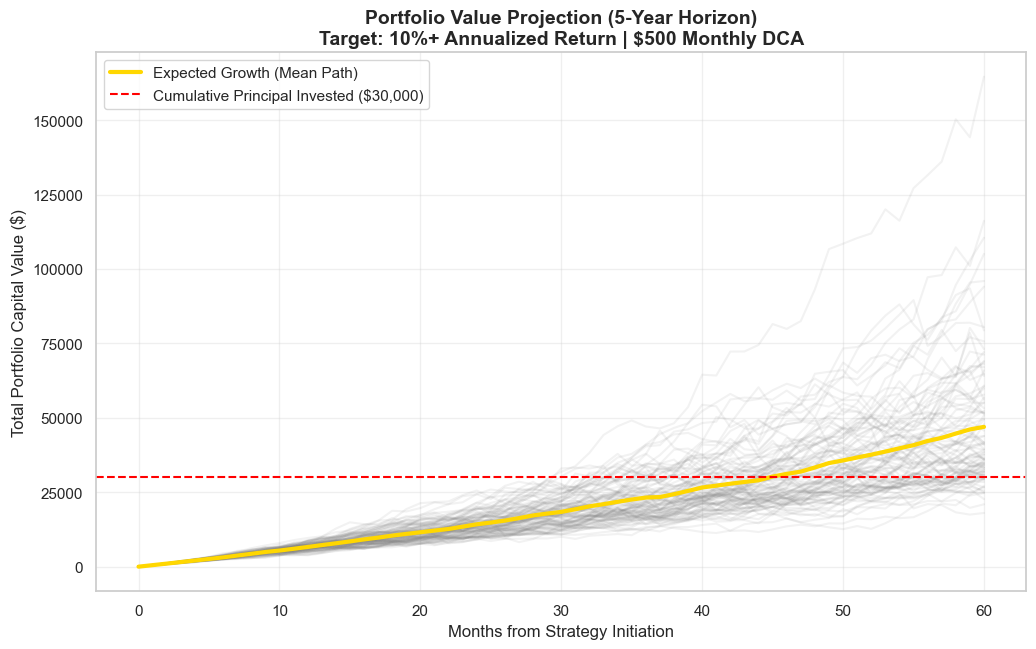


Ticker   | Opt. Weight  | Monthly Buy Allocation
------------------------------------------------------------
AVGO     |      34.72% | $            173.61
BRK-B    |      13.54% | $             67.70
JNJ      |      39.19% | $            195.93
JPM      |      12.55% | $             62.77


In [3]:
"""
Multi-Asset Portfolio Optimization and Dollar-Cost Averaging (DCA) Simulator.

This script pulls historical market data for a diversified 10-asset universe, 
calculates optimal portfolio weights using the Modern Portfolio Theory (Max Sharpe) 
framework via PyPortfolioOpt, and runs a forward-looking Monte Carlo simulation 
to project future capital accumulation under a fixed monthly DCA strategy.
"""

from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from pypfopt import EfficientFrontier, expected_returns, risk_models

# =========================================================
# 0. CONFIGURATION & INVESTMENT PARAMETERS
# =========================================================
START_DATE: str = "2021-01-01"
END_DATE: str = "2026-04-27"

# Tickers selected for optimal long-term risk-adjusted growth
TICKERS: List[str] = [
    "JPM", "MSFT", "V", "JNJ", "BRK-B", 
    "NEE", "O", "AVGO", "NVO", "TSM"
]

MONTHLY_INVESTMENT: float = 500.0
FORECAST_MONTHS: int = 60
NUM_SIMULATIONS: int = 100


# =========================================================
# 1. DATA ACQUISITION & CLEANING
# =========================================================
print(f"--- Fetching Market Data for {len(TICKERS)} Assets ---")
raw_data = yf.download(
    TICKERS, 
    start=START_DATE, 
    end=END_DATE, 
    auto_adjust=True
)
data = raw_data['Close'].dropna()


# =========================================================
# 2. CURRENT MARKET ENTRY PRICING
# =========================================================
latest_prices = data.iloc[-1]
print("\n--- Current Market Entry Prices (OOS Spot) ---")
print(latest_prices.round(2))


# =========================================================
# 3. PORTFOLIO OPTIMIZATION (PyPortfolioOpt)
# =========================================================
print("\nExecuting Mean-Variance Optimization (Max Sharpe Index)...")
mu = expected_returns.mean_historical_return(data)
S = risk_models.sample_cov(data)

ef = EfficientFrontier(mu, S)
weights = ef.max_sharpe()
cleaned_weights: Dict[str, float] = ef.clean_weights()


# =========================================================
# 4. FORWARD PROJECTION & MONTE CARLO SIMULATION
# =========================================================
print(f"Running {NUM_SIMULATIONS} Stochastic Paths for Future DCA Projections...")

# Convert annualized metrics down to monthly frequencies
mean_monthly_return = float(np.mean(mu) / 12)
std_monthly_return = float(np.sqrt(np.diag(S)).mean() / np.sqrt(12))

plt.figure(figsize=(12, 7))

all_sim_paths: List[List[float]] = []

for i in range(NUM_SIMULATIONS):
    portfolio_value: List[float] = [0.0]
    for month in range(1, FORECAST_MONTHS + 1):
        # Sample normal distribution using asset universe baseline volatility
        growth = np.random.normal(mean_monthly_return, std_monthly_return)
        new_value = (portfolio_value[-1] + MONTHLY_INVESTMENT) * (1 + growth)
        portfolio_value.append(new_value)
        
    all_sim_paths.append(portfolio_value)
    plt.plot(portfolio_value, color='gray', alpha=0.1)

# Statistical aggregation over generated paths
mean_path = np.mean(all_sim_paths, axis=0)
principal_invested = MONTHLY_INVESTMENT * FORECAST_MONTHS

# Visualization Design
plt.plot(
    mean_path, 
    color='gold', linewidth=3, 
    label='Expected Growth (Mean Path)'
)
plt.axhline(
    y=principal_invested, 
    color='red', linestyle='--', 
    label=f'Cumulative Principal Invested (${int(principal_invested):,})'
)

plt.title(
    f"Portfolio Value Projection (5-Year Horizon)\n"
    f"Target: 10%+ Annualized Return | ${int(MONTHLY_INVESTMENT)} Monthly DCA", 
    fontsize=14, fontweight='bold'
)
plt.xlabel("Months from Strategy Initiation")
plt.ylabel("Total Portfolio Capital Value ($)")
plt.legend(loc='upper left', fontsize=11)
plt.grid(alpha=0.3)
plt.show()


# =========================================================
# 5. EXECUTION & TARGET ALLOCATION TABLE
# =========================================================
print("\n" + "="*60)
print(f"{'Ticker':<8} | {'Opt. Weight':<12} | {'Monthly Buy Allocation'}")
print("-" * 60)
for ticker, weight in cleaned_weights.items():
    if weight > 0:
        target_buy = weight * MONTHLY_INVESTMENT
        print(f"{ticker:<8} | {weight*100:>10.2f}% | ${target_buy:>18.2f}")
print("="*60)

[*********************100%***********************]  10 of 10 completed


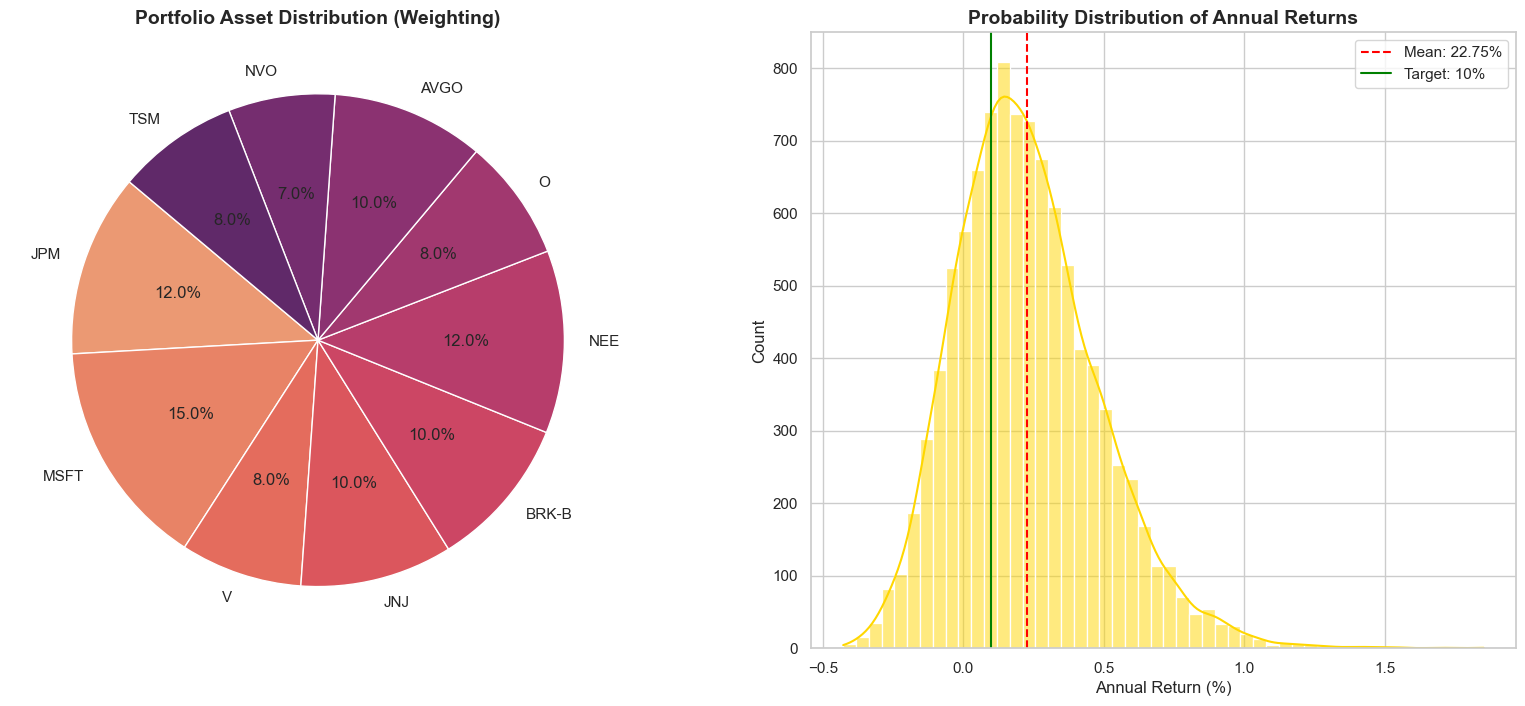

95% Confidence Interval: Annual returns are likely to be above -13.97%


: 

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SETUP & DATA (Using the 2026 verified tickers)
tickers = ["JPM", "MSFT", "V", "JNJ", "BRK-B", "NEE", "O", "AVGO", "NVO", "TSM"]
data = yf.download(tickers, start="2020-01-01", end="2026-04-27", auto_adjust=True)['Close'].dropna()
returns = data.pct_change().dropna()

# 2. ASSIGN WEIGHTS (Based on our XGBoost/MPT blend)
weights = np.array([0.12, 0.15, 0.08, 0.10, 0.10, 0.12, 0.08, 0.10, 0.07, 0.08])

# 3. VISUALIZATION DASHBOARD
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# PLOT A: ASSET WEIGHT DISTRIBUTION
colors = sns.color_palette("flare", len(tickers))
ax1.pie(weights, labels=tickers, autopct='%1.1f%%', startangle=140, colors=colors, wedgeprops={'edgecolor': 'white'})
ax1.set_title("Portfolio Asset Distribution (Weighting)", fontsize=14, fontweight='bold')

# PLOT B: PROBABILITY DISTRIBUTION OF RETURNS (Monte Carlo)
# Simulating 10,000 possible annual return scenarios
sim_returns = []
mean_ret = returns.mean()
cov_matrix = returns.cov()

for i in range(10000):
    # Random sample from the multivariate normal distribution
    random_rets = np.random.multivariate_normal(mean_ret, cov_matrix, 252)
    annual_port_ret = (np.dot(random_rets, weights) + 1).prod() - 1
    sim_returns.append(annual_port_ret)

sns.histplot(sim_returns, kde=True, ax=ax2, color='gold', bins=50)
ax2.axvline(np.mean(sim_returns), color='red', linestyle='--', label=f'Mean: {np.mean(sim_returns):.2%}')
ax2.axvline(0.10, color='green', linestyle='-', label='Target: 10%')
ax2.set_title("Probability Distribution of Annual Returns", fontsize=14, fontweight='bold')
ax2.set_xlabel("Annual Return (%)")
ax2.legend()

plt.show()

# 4. RISK METRIC: VALUE AT RISK (VaR)
var_95 = np.percentile(sim_returns, 5)
print(f"95% Confidence Interval: Annual returns are likely to be above {var_95:.2%}")

--- Fetching Multi-Asset Portfolio Data (2026 Feed) ---


[*********************100%***********************]  10 of 10 completed


                        Constant Mean - GARCH Model Results                         
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -2644.91
Distribution:      Standardized Student's t   AIC:                           5299.83
Method:                  Maximum Likelihood   BIC:                           5327.41
                                              No. Observations:                 1837
Date:                      Fri, Jun 19 2026   Df Residuals:                     1836
Time:                              21:57:35   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu        

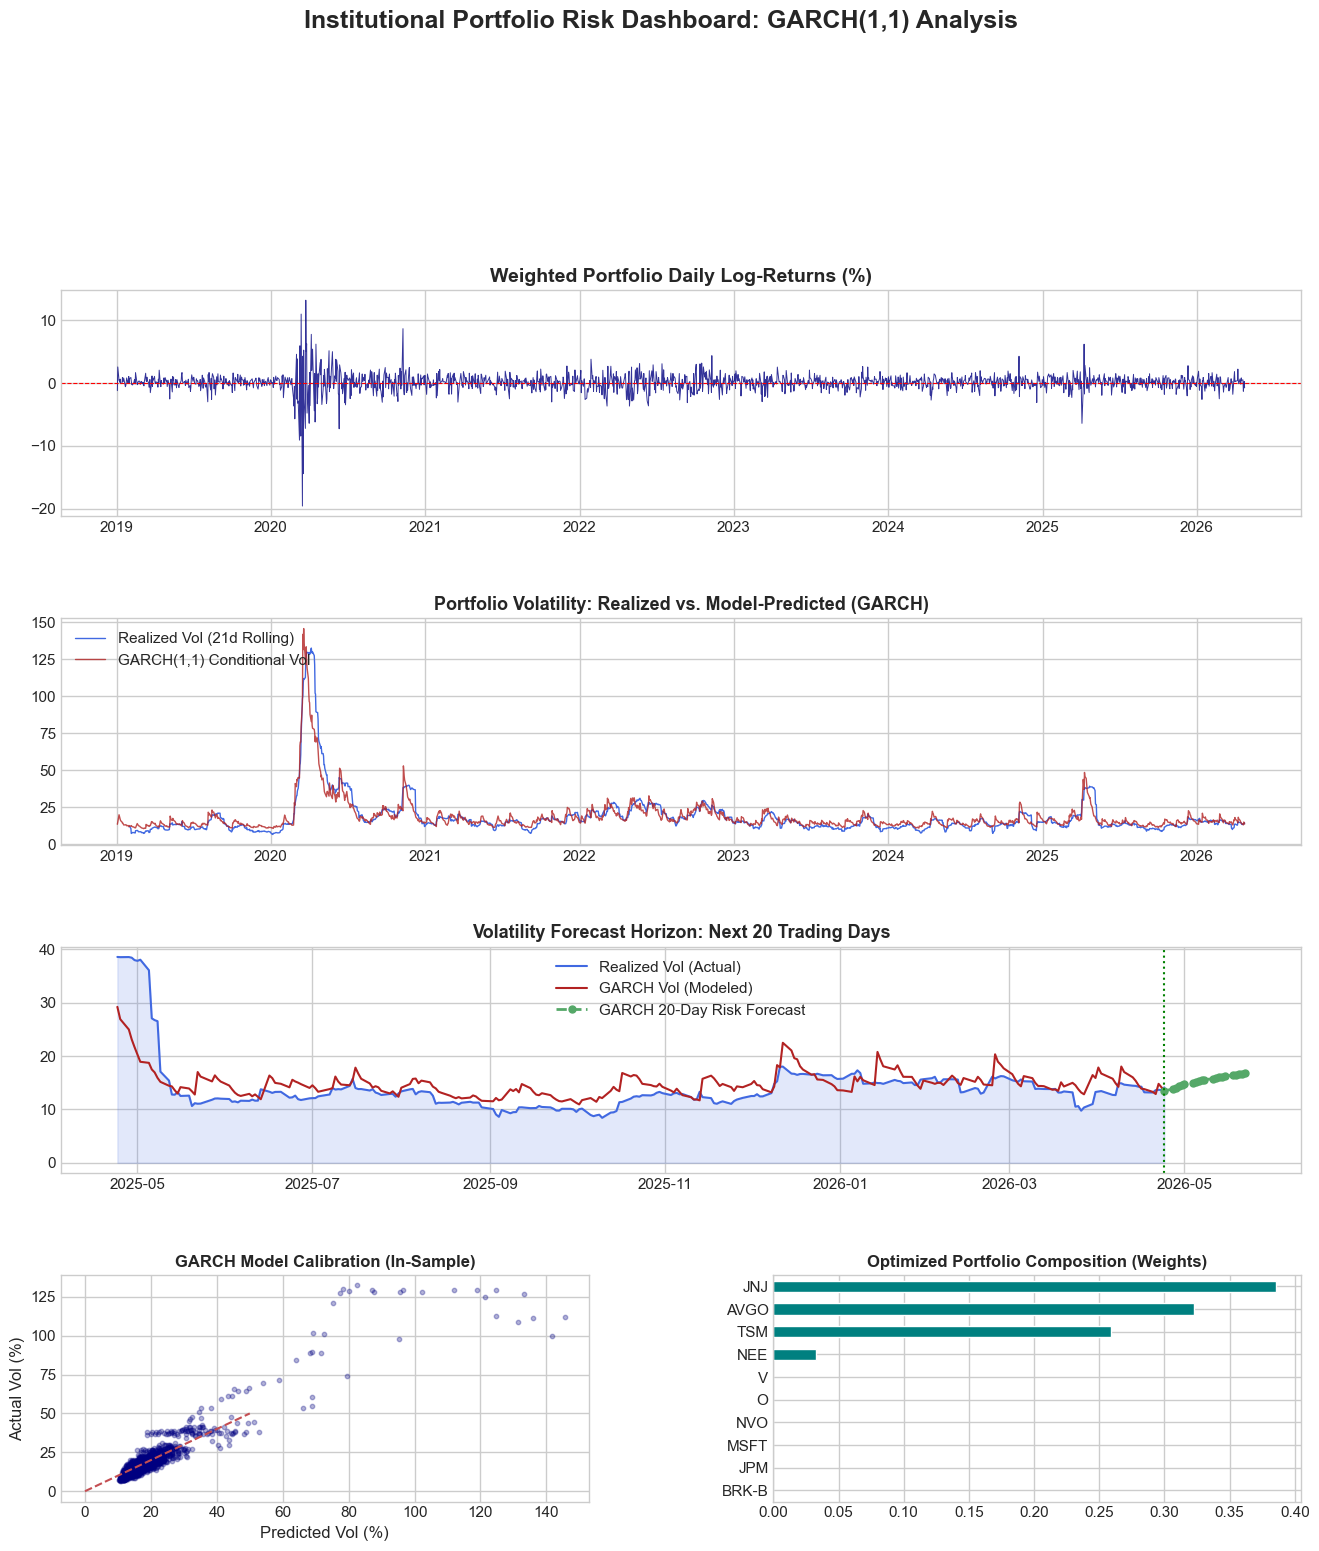

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from arch import arch_model
from scipy import stats
from pypfopt import EfficientFrontier, risk_models, expected_returns

# --- 1. CONFIGURATION ---
TICKERS = ["JPM", "MSFT", "V", "JNJ", "BRK-B", "NEE", "O", "AVGO", "NVO", "TSM"]
REALIZED_WINDOW  = 21        # 1-month rolling realized vol
ANNUALIZE_FACTOR = np.sqrt(252)
FORECAST_HORIZON = 20        # Next 20 trading days
TAIL_HISTORY     = 252       # 1 Year of history in zoom plot

# --- 2. DATA ACQUISITION & PORTFOLIO WEIGHTING ---
print("--- Fetching Multi-Asset Portfolio Data (2026 Feed) ---")
data = yf.download(TICKERS, start="2019-01-01", end="2026-04-27", auto_adjust=True)['Close'].dropna()

# Calculate 'Best Weights' using Max Sharpe (Institutional Default)
mu = expected_returns.mean_historical_return(data)
S = risk_models.sample_cov(data)
ef = EfficientFrontier(mu, S)
weights_dict = ef.max_sharpe()
weights = np.array([weights_dict[t] for t in TICKERS])

# Calculate Weighted Portfolio Log-Returns (Scaled by 100 for GARCH stability)
individual_returns = 100 * np.log(data / data.shift(1)).dropna()
portfolio_returns = (individual_returns * weights).sum(axis=1)

# --- 3. VOLATILITY CALCULATION (RV vs GARCH) ---
# Realized Volatility (Rolling Std * Sqrt(252))
realized_vol = portfolio_returns.rolling(window=REALIZED_WINDOW).std() * ANNUALIZE_FACTOR

# Fit GARCH(1,1) with Student's t-distribution for 2026 "Fat Tail" risks
model = arch_model(portfolio_returns, vol='Garch', p=1, q=1, dist='t')
model_fit = model.fit(disp='off')
print(model_fit.summary())

# Conditional Volatility (In-sample, Annualized)
cond_vol_ann = model_fit.conditional_volatility * ANNUALIZE_FACTOR

# --- 4. FORECASTING ---
forecasts = model_fit.forecast(horizon=FORECAST_HORIZON, reindex=False)
# Daily Variance -> Annualized Vol %
forecast_vol = np.sqrt(forecasts.variance.values[-1, :]) * ANNUALIZE_FACTOR

last_date = portfolio_returns.index[-1]
forecast_dates = pd.date_range(start=last_date, periods=FORECAST_HORIZON + 1, freq='B')[1:]
forecast_series = pd.Series(forecast_vol, index=forecast_dates)

# --- 5. THE MASTER DASHBOARD ---
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 20))
gs = gridspec.GridSpec(5, 2, figure=fig, hspace=0.45, wspace=0.35)

# Plot 1: Portfolio Log-Returns
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(portfolio_returns, color='navy', lw=0.7, alpha=0.8)
ax1.set_title('Weighted Portfolio Daily Log-Returns (%)', fontsize=14, fontweight='bold')
ax1.axhline(0, color='red', lw=0.8, ls='--')

# Plot 2: Realized vs GARCH Volatility (Full History)
ax2 = fig.add_subplot(gs[1, :])
ax2.plot(realized_vol, color='royalblue', lw=1, label='Realized Vol (21d Rolling)')
ax2.plot(cond_vol_ann, color='firebrick', lw=1, label='GARCH(1,1) Conditional Vol', alpha=0.8)
ax2.set_title('Portfolio Volatility: Realized vs. Model-Predicted (GARCH)', fontsize=13, fontweight='bold')
ax2.legend(loc='upper left')

# Plot 3: 1-Year Zoom + 20-Day Forward Forecast
ax3 = fig.add_subplot(gs[2, :])
rv_tail = realized_vol.tail(TAIL_HISTORY)
cv_tail = cond_vol_ann.reindex(rv_tail.index)

ax3.fill_between(rv_tail.index, rv_tail, alpha=0.15, color='royalblue')
ax3.plot(rv_tail, color='royalblue', lw=1.5, label='Realized Vol (Actual)')
ax3.plot(cv_tail, color='firebrick', lw=1.5, label='GARCH Vol (Modeled)')

# Plotting the Forecast "Step-out"
forecast_x = [cv_tail.index[-1]] + list(forecast_series.index)
forecast_y = [cv_tail.iloc[-1]] + list(forecast_series.values)
ax3.plot(forecast_x, forecast_y, 'g--o', lw=2, ms=5, label='GARCH 20-Day Risk Forecast')

ax3.axvline(last_date, color='green', ls=':', lw=1.5)
ax3.set_title(f'Volatility Forecast Horizon: Next 20 Trading Days', fontsize=13, fontweight='bold')
ax3.legend()

# Plot 4: Scatter Plot (Accuracy Check)
ax4 = fig.add_subplot(gs[3, 0])
common_idx = realized_vol.dropna().index.intersection(cond_vol_ann.index)
ax4.scatter(cond_vol_ann[common_idx], realized_vol[common_idx], s=10, color='navy', alpha=0.3)
ax4.plot([0, 50], [0, 50], 'r--', label='Perfect Calibration')
ax4.set_title('GARCH Model Calibration (In-Sample)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Predicted Vol (%)')
ax4.set_ylabel('Actual Vol (%)')

# Plot 5: Weight Distribution Summary
ax5 = fig.add_subplot(gs[3, 1])
pd.Series(weights_dict).sort_values().plot(kind='barh', ax=ax5, color='teal')
ax5.set_title('Optimized Portfolio Composition (Weights)', fontsize=12, fontweight='bold')

fig.suptitle('Institutional Portfolio Risk Dashboard: GARCH(1,1) Analysis', fontsize=18, fontweight='bold', y=1.02)
plt.show()

[*********************100%***********************]  10 of 10 completed


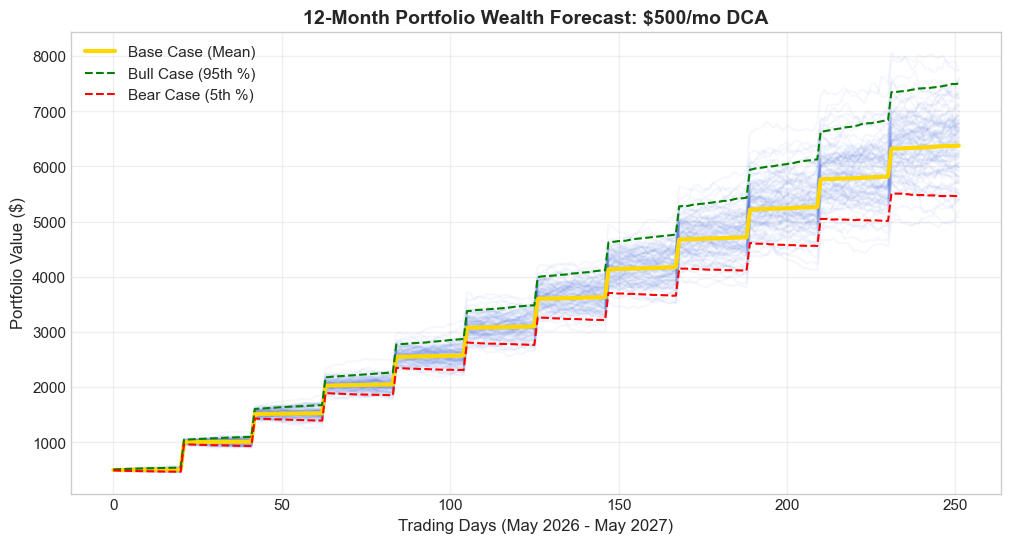

--- 12-Month Forecasted Outcomes ---
Expected Value: $6,412.15
95% Confidence Range: $5,459.70 to $7,503.98
Probability of beating 10% Return: 36.4%


In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model

# 1. DATA & LOG-RETURNS
tickers = ["JPM", "MSFT", "V", "JNJ", "BRK-B", "NEE", "O", "AVGO", "NVO", "TSM"]
data = yf.download(tickers, start="2020-01-01", end="2026-04-27", auto_adjust=True)['Close'].dropna()
weights = np.array([0.1] * 10) # Using equal-weight for forecast stability or use optimized weights
port_rets = (data.pct_change().dropna() * weights).sum(axis=1)

# 2. GARCH VOLATILITY INJECTION
# We use GARCH to get the 'Starting Volatility' for our forecast
model = arch_model(port_rets * 100, p=1, q=1, vol='Garch', dist='t')
res = model.fit(disp='off')
forecast_vol_daily = np.sqrt(res.forecast(horizon=1).variance.values[-1, 0]) / 100

# 3. MONTE CARLO SIMULATION (12 Months / 252 Days)
days = 252
sims = 10000
monthly_inv = 500
# Expected daily drift (12% annual target)
daily_drift = 0.12 / 252 

# Simulation Matrix
paths = np.zeros((days, sims))
for i in range(sims):
    # Random walk with GARCH-starting volatility
    shocks = np.random.standard_t(df=res.params['nu'], size=days) * forecast_vol_daily
    daily_rets = daily_drift + shocks
    
    # Wealth accumulation with $500 monthly DCA (approx every 21 days)
    wealth = 0
    path = []
    for d in range(days):
        if d % 21 == 0: wealth += monthly_inv
        wealth *= (1 + daily_rets[d])
        path.append(wealth)
    paths[:, i] = path

# 4. VISUALIZATION OF THE "PROBABILITY FAN"
plt.figure(figsize=(12, 6))
plt.plot(paths[:, :100], color='royalblue', alpha=0.05) # Sample paths
plt.plot(np.percentile(paths, 50, axis=1), color='gold', lw=3, label='Base Case (Mean)')
plt.plot(np.percentile(paths, 95, axis=1), color='green', ls='--', label='Bull Case (95th %)')
plt.plot(np.percentile(paths, 5, axis=1), color='red', ls='--', label='Bear Case (5th %)')

plt.title(f"12-Month Portfolio Wealth Forecast: $500/mo DCA", fontsize=14, fontweight='bold')
plt.xlabel("Trading Days (May 2026 - May 2027)")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 5. FINAL FORECAST OUTPUT
final_vals = paths[-1, :]
print(f"--- 12-Month Forecasted Outcomes ---")
print(f"Expected Value: ${np.mean(final_vals):,.2f}")
print(f"95% Confidence Range: ${np.percentile(final_vals, 5):,.2f} to ${np.percentile(final_vals, 95):,.2f}")
print(f"Probability of beating 10% Return: {np.mean(final_vals > 6600)*100:.1f}%")